# Lib1 Outer-Seed Prior HPO Analysis

This notebook analyzes the June 15 outer-split-seed, prior-informed, no-RC Lib1 HPO run.

Design reminders:

- Four parts only: Promoter, Intron, 3UTR, 5UTR.
- Enhancer is intentionally excluded.
- Validation metrics select configs; test metrics are diagnostic/final evidence only.
- The decision unit is `(part, config_id)` because every base hyperparameter config is repeated across split seeds `[101, 202, 303, 404, 505]` with fixed `model_seed=1701`.

The first half is registry/manifest-only and cheap. The final sections include optional W&B history export and checkpoint-level residual/barcode diagnostics, both disabled by default.


In [51]:
from pathlib import Path
import hashlib
import json
import math
import os
import sys
import tarfile
import tempfile
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_colwidth', 180)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180})

cwd = Path.cwd().resolve()
ROOT = cwd
while ROOT.name != 'boda2_EU' and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if ROOT.name != 'boda2_EU':
    if (cwd / 'boda2_EU').exists():
        ROOT = cwd / 'boda2_EU'
    else:
        raise RuntimeError('Could not find boda2_EU repo root from the current working directory')

REPO = ROOT.parent
LEARN = ROOT / 'src' / 'learn'
RUN_REGISTRY = LEARN / 'run_registry'
MANIFEST_DIR = LEARN / 'outputs' / 'hpo_manifests'
MANIFEST_TAG = 'lib1_outer_seed_prior_no_rc_june2026'
ANALYSIS_DIR = LEARN / 'outputs' / 'hpo_analyses' / MANIFEST_TAG
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PART_ORDER = ['Promoter', 'Intron', '3UTR', '5UTR']
PART_SLUG_ORDER = ['promoter', 'intron', 'utr3', 'utr5']
SPLIT_SEEDS = [101, 202, 303, 404, 505]
SOURCE_ORDER = ['exact_elite', 'local_variant', 'narrow_prior']
SPLIT_ORDER = ['train', 'val', 'test']

PART_COLORS = {
    'Promoter': '#b33146',
    'Intron': '#2f5f8f',
    '3UTR': '#5e3c99',
    '5UTR': '#2f7f4f',
}
SOURCE_COLORS = {
    'exact_elite': '#3b5b92',
    'local_variant': '#2f8f5b',
    'narrow_prior': '#a66a21',
}

ROOT, LEARN, ANALYSIS_DIR

(PosixPath('/home/minhang/synBio_AL/boda2_EU'),
 PosixPath('/home/minhang/synBio_AL/boda2_EU/src/learn'),
 PosixPath('/home/minhang/synBio_AL/boda2_EU/src/learn/outputs/hpo_analyses/lib1_outer_seed_prior_no_rc_june2026'))

## Load Manifest And Registry

The manifest is the source of the experimental design. `runs.csv` is the source of completed outcomes. The merge key is the deterministic `planned_run_name` produced by the launcher.


In [52]:
run_manifest_path = MANIFEST_DIR / f'{MANIFEST_TAG}__run_manifest.csv'
base_config_path = MANIFEST_DIR / f'{MANIFEST_TAG}__base_configs.csv'
runs_path = RUN_REGISTRY / 'runs.csv'

manifest = pd.read_csv(run_manifest_path, low_memory=False)
base_configs = pd.read_csv(base_config_path, low_memory=False)
runs = pd.read_csv(runs_path, low_memory=False)

metric_cols = [
    'best_metric_value', 'best_epoch',
    'train_pearson', 'val_pearson', 'test_pearson',
    'train_spearman', 'val_spearman', 'test_spearman',
    'train_mse', 'val_mse', 'test_mse',
    'train_cod_r2', 'val_cod_r2', 'test_cod_r2',
    'train_loss', 'val_loss', 'test_loss',
    'train_pearson_r2', 'val_pearson_r2', 'test_pearson_r2',
]
for frame in [manifest, base_configs, runs]:
    for col in metric_cols + ['split_seed', 'model_seed', 'manifest_row']:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors='coerce')

outer = manifest.merge(
    runs,
    left_on='planned_run_name',
    right_on='run_name',
    how='left',
    suffixes=('_manifest', '_registry'),
)

# Restore common names after suffixing.
for col in ['run_name', 'model_module', 'data_module', 'graph_module', 'logger_project', 'artifact_path']:
    mcol = f'{col}_manifest'
    rcol = f'{col}_registry'
    if rcol in outer.columns and mcol in outer.columns:
        outer[col] = outer[rcol].combine_first(outer[mcol])
    elif rcol in outer.columns:
        outer[col] = outer[rcol]
    elif mcol in outer.columns:
        outer[col] = outer[mcol]

outer['part'] = pd.Categorical(outer['part'], categories=PART_ORDER, ordered=True)
outer['config_source'] = pd.Categorical(outer['config_source'], categories=SOURCE_ORDER, ordered=True)
outer['split_seed'] = pd.to_numeric(outer['split_seed'], errors='coerce').astype('Int64')
outer['model_seed'] = pd.to_numeric(outer['model_seed'], errors='coerce').astype('Int64')
outer['selection_ready'] = (
    outer['status'].eq('completed')
    & outer['val_pearson'].notna()
    & outer['test_pearson'].notna()
    & outer[['train_pearson', 'val_pearson', 'test_pearson']].abs().le(1).all(axis=1)
)
outer['architecture'] = np.where(outer['model_module'].astype(str).str.contains('Basset', case=False, na=False), 'BassetVL', 'ResNet1D')
outer['config_short'] = outer['config_id'].astype(str).str.replace('_cfg', '#', regex=False)

completion_audit = pd.DataFrame([{
    'manifest_rows': len(manifest),
    'base_config_rows': len(base_configs),
    'registry_matches': int(outer['run_id'].notna().sum()),
    'completed_rows': int(outer['status'].eq('completed').sum()),
    'selection_ready_rows': int(outer['selection_ready'].sum()),
    'duplicate_run_names': int(outer['planned_run_name'].duplicated().sum()),
    'missing_registry_rows': int(outer['run_id'].isna().sum()),
    'parts': ', '.join(map(str, sorted(outer['part'].dropna().astype(str).unique()))),
    'rc_values': ', '.join(map(str, sorted(outer['use_reverse_complements'].dropna().astype(str).unique()))),
    'model_seeds': ', '.join(map(str, sorted(map(int, outer['model_seed'].dropna().unique())))),
}])

display(completion_audit)
display(outer.groupby(['part'], observed=True).agg(
    rows=('planned_run_name', 'count'),
    completed=('status', lambda s: int((s == 'completed').sum())),
    selection_ready=('selection_ready', 'sum'),
    base_configs=('config_id', 'nunique'),
    split_seeds=('split_seed', lambda s: sorted(map(int, s.dropna().unique()))),
).reset_index())


,manifest_rows,base_config_rows,registry_matches,completed_rows,selection_ready_rows,duplicate_run_names,missing_registry_rows,parts,rc_values,model_seeds
0,600,120,600,600,600,0,0,"3UTR, 5UTR, Intron, Promoter",False,1701


,part,rows,completed,selection_ready,base_configs,split_seeds
0,Promoter,150,150,150,30,"[101, 202, 303, 404, 505]"
1,Intron,150,150,150,30,"[101, 202, 303, 404, 505]"
2,3UTR,150,150,150,30,"[101, 202, 303, 404, 505]"
3,5UTR,150,150,150,30,"[101, 202, 303, 404, 505]"


In [53]:
# Design assertions. These should all pass for the intended 600-run campaign.
assert len(manifest) == 600, len(manifest)
assert len(base_configs) == 120, len(base_configs)
assert outer['run_id'].notna().sum() == 600, outer['run_id'].notna().sum()
assert set(outer['part'].astype(str).unique()) == set(PART_ORDER), set(outer['part'].astype(str).unique())
assert not set(outer['part'].astype(str).unique()) & {'Enhancer'}
assert set(outer['use_reverse_complements'].astype(str).unique()) <= {'False', '0', 'false'}
assert set(map(int, outer['model_seed'].dropna().unique())) == {1701}
seed_counts = outer.groupby(['part', 'config_id'], observed=True)['split_seed'].nunique()
assert (seed_counts == len(SPLIT_SEEDS)).all(), seed_counts[seed_counts != len(SPLIT_SEEDS)]
print('Design audit passed: 4 parts, 120 base configs, 600 completed rows, no RC, fixed model_seed, five split seeds per config.')


Design audit passed: 4 parts, 120 base configs, 600 completed rows, no RC, fixed model_seed, five split seeds per config.


## Validation-First Config Summary

There are two object levels in this analysis:

- A run-level row is one training job: one `(part, config_id, split_seed)` datapoint.
- A config-level row collapses the five run-level rows that share the same `(part, config_id)` across split seeds `[101, 202, 303, 404, 505]`.

Primary ranking selects one config per part by `val_pearson_mean`, the mean validation Pearson across those five split-seed runs. Test metrics are retained as diagnostic columns only. `mean_seed_rank_val` is a separate robustness diagnostic: each split seed ranks all 30 configs within the part, then the config's five ranks are averaged. A mean-validation winner only has `mean_seed_rank_val = 1` if it is rank 1 on every split seed.


In [54]:
# Rank each run within its part/seed slice. This helps identify configs that are consistently good,
# not just lucky on one heldout split.
outer['rank_within_part_seed_val'] = outer.groupby(['part', 'split_seed'], observed=True)['val_pearson'].rank(ascending=False, method='min')
outer['rank_within_part_seed_test_diagnostic'] = outer.groupby(['part', 'split_seed'], observed=True)['test_pearson'].rank(ascending=False, method='min')
outer['top1_within_seed_val'] = outer['rank_within_part_seed_val'].eq(1)
outer['top3_within_seed_val'] = outer['rank_within_part_seed_val'].le(3)
outer['top5_within_seed_val'] = outer['rank_within_part_seed_val'].le(5)

config_summary = outer.groupby(['part', 'part_slug', 'architecture', 'config_id', 'config_source'], observed=True).agg(
    n_runs=('run_id', 'count'),
    n_split_seeds=('split_seed', 'nunique'),
    val_pearson_mean=('val_pearson', 'mean'),
    val_pearson_std=('val_pearson', 'std'),
    val_pearson_min=('val_pearson', 'min'),
    val_pearson_max=('val_pearson', 'max'),
    val_spearman_mean=('val_spearman', 'mean'),
    val_cod_r2_mean=('val_cod_r2', 'mean'),
    val_mse_mean=('val_mse', 'mean'),
    test_pearson_mean_diagnostic=('test_pearson', 'mean'),
    test_pearson_std_diagnostic=('test_pearson', 'std'),
    test_pearson_min_diagnostic=('test_pearson', 'min'),
    test_pearson_max_diagnostic=('test_pearson', 'max'),
    train_pearson_mean=('train_pearson', 'mean'),
    best_epoch_mean=('best_epoch', 'mean'),
    best_epoch_min=('best_epoch', 'min'),
    best_epoch_max=('best_epoch', 'max'),
    mean_seed_rank_val=('rank_within_part_seed_val', 'mean'),
    median_seed_rank_val=('rank_within_part_seed_val', 'median'),
    worst_seed_rank_val=('rank_within_part_seed_val', 'max'),
    top1_seed_count=('top1_within_seed_val', 'sum'),
    top3_seed_count=('top3_within_seed_val', 'sum'),
    top5_seed_count=('top5_within_seed_val', 'sum'),
    source_prior_sweep_id=('source_prior_sweep_id', 'first'),
    source_run_id=('source_run_id', 'first'),
    source_val_pearson=('source_val_pearson', 'first'),
    source_test_pearson_diagnostic=('source_test_pearson', 'first'),
    prior_selection_score=('prior_selection_score', 'first'),
).reset_index()

config_summary['val_pearson_sem'] = config_summary['val_pearson_std'] / np.sqrt(config_summary['n_split_seeds'])
# t_{0.975, df=4} ~= 2.776. With n=5 this is descriptive, not a high-precision population CI.
config_summary['val_pearson_t95_halfwidth'] = 2.776 * config_summary['val_pearson_sem']
config_summary['val_pearson_seed_range'] = config_summary['val_pearson_max'] - config_summary['val_pearson_min']
config_summary['test_pearson_seed_range_diagnostic'] = config_summary['test_pearson_max_diagnostic'] - config_summary['test_pearson_min_diagnostic']
config_summary['val_mean_minus_sd'] = config_summary['val_pearson_mean'] - config_summary['val_pearson_std'].fillna(0)
config_summary['val_mean_minus_t95'] = config_summary['val_pearson_mean'] - config_summary['val_pearson_t95_halfwidth'].fillna(0)
config_summary['rank_val_mean'] = config_summary.groupby('part', observed=True)['val_pearson_mean'].rank(ascending=False, method='min').astype(int)
config_summary['rank_val_mean_minus_sd'] = config_summary.groupby('part', observed=True)['val_mean_minus_sd'].rank(ascending=False, method='min').astype(int)
config_summary['rank_diagnostic_test_mean'] = config_summary.groupby('part', observed=True)['test_pearson_mean_diagnostic'].rank(ascending=False, method='min').astype(int)
config_summary = config_summary.sort_values(['part', 'rank_val_mean', 'config_id'])

winner_by_val = config_summary.loc[config_summary.groupby('part', observed=True)['rank_val_mean'].idxmin()].sort_values('part')

display(winner_by_val[[
    'part', 'architecture', 'config_id', 'config_source', 'n_split_seeds',
    'val_pearson_mean', 'val_pearson_std', 'val_pearson_min', 'val_pearson_max', 'val_pearson_seed_range', 'val_pearson_t95_halfwidth',
    'mean_seed_rank_val', 'worst_seed_rank_val', 'top1_seed_count', 'top3_seed_count', 'top5_seed_count',
    'test_pearson_mean_diagnostic', 'test_pearson_std_diagnostic', 'test_pearson_min_diagnostic', 'test_pearson_max_diagnostic', 'test_pearson_seed_range_diagnostic', 'best_epoch_mean',
]].style.format(precision=4))

winner_spread_summary = winner_by_val[[
    'part', 'config_id', 'config_source', 'n_split_seeds',
    'val_pearson_mean', 'val_pearson_std', 'val_pearson_min', 'val_pearson_max', 'val_pearson_seed_range',
    'mean_seed_rank_val', 'worst_seed_rank_val',
    'test_pearson_mean_diagnostic', 'test_pearson_std_diagnostic',
    'test_pearson_min_diagnostic', 'test_pearson_max_diagnostic', 'test_pearson_seed_range_diagnostic',
]].copy()
display(winner_spread_summary.style.format(precision=4))

print('Part winners with split-seed spread:')
for _, row in winner_spread_summary.iterrows():
    print(
        f"- {row['part']} winner: {row['config_id']}; "
        f"val Pearson {row['val_pearson_mean']:.3f} +/- {row['val_pearson_std']:.3f} SD "
        f"across {int(row['n_split_seeds'])} split seeds "
        f"(range {row['val_pearson_min']:.3f}-{row['val_pearson_max']:.3f}); "
        f"diagnostic test Pearson {row['test_pearson_mean_diagnostic']:.3f} +/- {row['test_pearson_std_diagnostic']:.3f} SD "
        f"(range {row['test_pearson_min_diagnostic']:.3f}-{row['test_pearson_max_diagnostic']:.3f})."
    )

top5_by_part = config_summary.groupby('part', observed=True).head(5).copy()
display(top5_by_part[[
    'part', 'rank_val_mean', 'config_id', 'config_source', 'val_pearson_mean', 'val_pearson_std',
    'val_pearson_min', 'val_pearson_max', 'mean_seed_rank_val', 'top3_seed_count',
    'test_pearson_mean_diagnostic', 'rank_diagnostic_test_mean',
]].style.format(precision=4))


,part,architecture,config_id,config_source,n_split_seeds,val_pearson_mean,val_pearson_std,val_pearson_min,val_pearson_max,val_pearson_seed_range,val_pearson_t95_halfwidth,mean_seed_rank_val,worst_seed_rank_val,top1_seed_count,top3_seed_count,top5_seed_count,test_pearson_mean_diagnostic,test_pearson_std_diagnostic,test_pearson_min_diagnostic,test_pearson_max_diagnostic,test_pearson_seed_range_diagnostic,best_epoch_mean
10,Promoter,BassetVL,promoter_cfg011,local_variant,5,0.4547,0.0702,0.3510,0.5339,0.1829,0.0872,6.4000,17.0000,0,2,4,0.4408,0.0818,0.3648,0.5656,0.2008,123.8000
40,Intron,ResNet1D,intron_cfg011,local_variant,5,0.6174,0.0573,0.5572,0.7094,0.1522,0.0712,3.0000,7.0000,3,3,4,0.6461,0.0442,0.5678,0.6742,0.1064,88.0000
60,3UTR,ResNet1D,utr3_cfg001,exact_elite,5,0.3783,0.0760,0.3050,0.5054,0.2004,0.0944,3.4000,6.0000,2,2,4,0.3713,0.1347,0.1948,0.5044,0.3096,78.2000
96,5UTR,ResNet1D,utr5_cfg007,exact_elite,5,0.4961,0.0216,0.4641,0.5200,0.0559,0.0268,3.6000,5.0000,0,3,5,0.4247,0.0482,0.3608,0.4924,0.1316,166.4000


,part,config_id,config_source,n_split_seeds,val_pearson_mean,val_pearson_std,val_pearson_min,val_pearson_max,val_pearson_seed_range,mean_seed_rank_val,worst_seed_rank_val,test_pearson_mean_diagnostic,test_pearson_std_diagnostic,test_pearson_min_diagnostic,test_pearson_max_diagnostic,test_pearson_seed_range_diagnostic
10,Promoter,promoter_cfg011,local_variant,5,0.4547,0.0702,0.3510,0.5339,0.1829,6.4000,17.0000,0.4408,0.0818,0.3648,0.5656,0.2008
40,Intron,intron_cfg011,local_variant,5,0.6174,0.0573,0.5572,0.7094,0.1522,3.0000,7.0000,0.6461,0.0442,0.5678,0.6742,0.1064
60,3UTR,utr3_cfg001,exact_elite,5,0.3783,0.0760,0.3050,0.5054,0.2004,3.4000,6.0000,0.3713,0.1347,0.1948,0.5044,0.3096
96,5UTR,utr5_cfg007,exact_elite,5,0.4961,0.0216,0.4641,0.5200,0.0559,3.6000,5.0000,0.4247,0.0482,0.3608,0.4924,0.1316


Part winners with split-seed spread:
- Promoter winner: promoter_cfg011; val Pearson 0.455 +/- 0.070 SD across 5 split seeds (range 0.351-0.534); diagnostic test Pearson 0.441 +/- 0.082 SD (range 0.365-0.566).
- Intron winner: intron_cfg011; val Pearson 0.617 +/- 0.057 SD across 5 split seeds (range 0.557-0.709); diagnostic test Pearson 0.646 +/- 0.044 SD (range 0.568-0.674).
- 3UTR winner: utr3_cfg001; val Pearson 0.378 +/- 0.076 SD across 5 split seeds (range 0.305-0.505); diagnostic test Pearson 0.371 +/- 0.135 SD (range 0.195-0.504).
- 5UTR winner: utr5_cfg007; val Pearson 0.496 +/- 0.022 SD across 5 split seeds (range 0.464-0.520); diagnostic test Pearson 0.425 +/- 0.048 SD (range 0.361-0.492).


,part,rank_val_mean,config_id,config_source,val_pearson_mean,val_pearson_std,val_pearson_min,val_pearson_max,mean_seed_rank_val,top3_seed_count,test_pearson_mean_diagnostic,rank_diagnostic_test_mean
10,Promoter,1,promoter_cfg011,local_variant,0.4547,0.0702,0.3510,0.5339,6.4000,2,0.4408,1
28,Promoter,2,promoter_cfg029,narrow_prior,0.4543,0.0817,0.3334,0.5394,6.6000,2,0.4280,7
13,Promoter,3,promoter_cfg014,local_variant,0.4533,0.0846,0.3444,0.5588,7.2000,2,0.4291,5
17,Promoter,4,promoter_cfg018,local_variant,0.4525,0.0822,0.3362,0.5519,7.2000,1,0.4309,4
12,Promoter,5,promoter_cfg013,local_variant,0.4498,0.0759,0.3388,0.5442,7.8000,0,0.4282,6
40,Intron,1,intron_cfg011,local_variant,0.6174,0.0573,0.5572,0.7094,3.0000,3,0.6461,1
42,Intron,2,intron_cfg013,local_variant,0.5982,0.0476,0.5588,0.6809,6.4000,1,0.5986,12
38,Intron,3,intron_cfg009,local_variant,0.5958,0.0619,0.5446,0.6997,6.0000,2,0.5975,15
43,Intron,4,intron_cfg014,local_variant,0.5917,0.0469,0.5561,0.6719,9.4000,1,0.5892,25
32,Intron,5,intron_cfg003,exact_elite,0.5914,0.0644,0.5220,0.6960,7.0000,3,0.5971,16


In [55]:
source_summary = outer.groupby(['part', 'config_source'], observed=True).agg(
    runs=('run_id', 'count'),
    configs=('config_id', 'nunique'),
    val_pearson_mean=('val_pearson', 'mean'),
    val_pearson_std=('val_pearson', 'std'),
    test_pearson_mean_diagnostic=('test_pearson', 'mean'),
    train_pearson_mean=('train_pearson', 'mean'),
).reset_index().sort_values(['part', 'config_source'])

display(source_summary.style.format(precision=4))

# Save the main analysis tables for reuse outside the notebook.
outer.to_csv(ANALYSIS_DIR / 'outer_seed_run_table.csv', index=False)
config_summary.to_csv(ANALYSIS_DIR / 'outer_seed_config_summary.csv', index=False)
source_summary.to_csv(ANALYSIS_DIR / 'outer_seed_config_source_summary.csv', index=False)
print(f'Wrote analysis tables under {ANALYSIS_DIR}')


,part,config_source,runs,configs,val_pearson_mean,val_pearson_std,test_pearson_mean_diagnostic,train_pearson_mean
0,Promoter,exact_elite,40,8,0.4372,0.0775,0.4156,0.4599
1,Promoter,local_variant,60,12,0.4390,0.0730,0.4143,0.4381
2,Promoter,narrow_prior,50,10,0.4147,0.0766,0.4063,0.4530
3,Intron,exact_elite,40,8,0.5806,0.0530,0.5952,0.5042
4,Intron,local_variant,60,12,0.5838,0.0530,0.5983,0.5205
5,Intron,narrow_prior,50,10,0.5235,0.0593,0.6089,0.5763
6,3UTR,exact_elite,40,8,0.2680,0.0930,0.2514,0.5011
7,3UTR,local_variant,60,12,0.2358,0.0913,0.2527,0.5346
8,3UTR,narrow_prior,50,10,0.2237,0.0854,0.2442,0.4896
9,5UTR,exact_elite,40,8,0.4780,0.0287,0.4143,0.4443


Wrote analysis tables under /home/minhang/synBio_AL/boda2_EU/src/learn/outputs/hpo_analyses/lib1_outer_seed_prior_no_rc_june2026


## Overview Plots

These mirror the earlier HPO notebooks: validation-vs-test scatter, source-family distributions, seed difficulty, and top-config robustness plots. Selection remains validation-first.


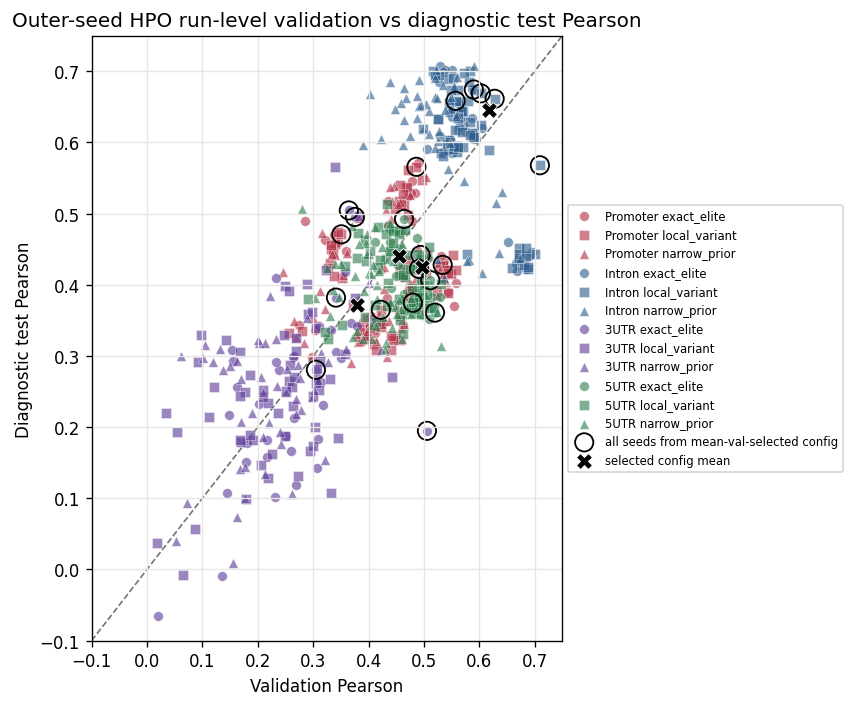

In [56]:
def _ordered_parts(frame):
    present = set(frame['part'].astype(str))
    return [p for p in PART_ORDER if p in present]


def plot_val_vs_test_runs(df):
    plot_df = df[df['selection_ready']].copy()
    fig, ax = plt.subplots(figsize=(7.2, 6.0))
    for part in _ordered_parts(plot_df):
        sub = plot_df[plot_df['part'].astype(str).eq(part)]
        for source, marker in [('exact_elite', 'o'), ('local_variant', 's'), ('narrow_prior', '^')]:
            ss = sub[sub['config_source'].astype(str).eq(source)]
            if ss.empty:
                continue
            ax.scatter(
                ss['val_pearson'], ss['test_pearson'],
                s=34, alpha=0.62, marker=marker,
                color=PART_COLORS.get(part, '0.45'),
                edgecolors='white', linewidths=0.35,
                label=f'{part} {source}',
            )
    winners = plot_df.merge(winner_by_val[['part', 'config_id']], on=['part', 'config_id'], how='inner')
    ax.scatter(
        winners['val_pearson'], winners['test_pearson'],
        s=120, facecolors='none', edgecolors='black', linewidths=1.1,
        label='all seeds from mean-val-selected config',
    )
    winner_means = config_summary.merge(winner_by_val[['part', 'config_id']], on=['part', 'config_id'], how='inner')
    ax.scatter(
        winner_means['val_pearson_mean'], winner_means['test_pearson_mean_diagnostic'],
        s=90, marker='X', color='black', edgecolors='white', linewidths=0.5,
        label='selected config mean', zorder=4,
    )
    values = plot_df[['val_pearson', 'test_pearson']].to_numpy(dtype=float)
    lo = max(-0.1, float(np.nanmin(values)) - 0.04)
    hi = min(1.0, float(np.nanmax(values)) + 0.04)
    ax.plot([lo, hi], [lo, hi], color='0.45', linestyle='--', linewidth=1, zorder=0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Validation Pearson')
    ax.set_ylabel('Diagnostic test Pearson')
    ax.set_title('Outer-seed HPO run-level validation vs diagnostic test Pearson')
    ax.grid(color='0.9')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7, frameon=True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_val_vs_test_runs(outer)


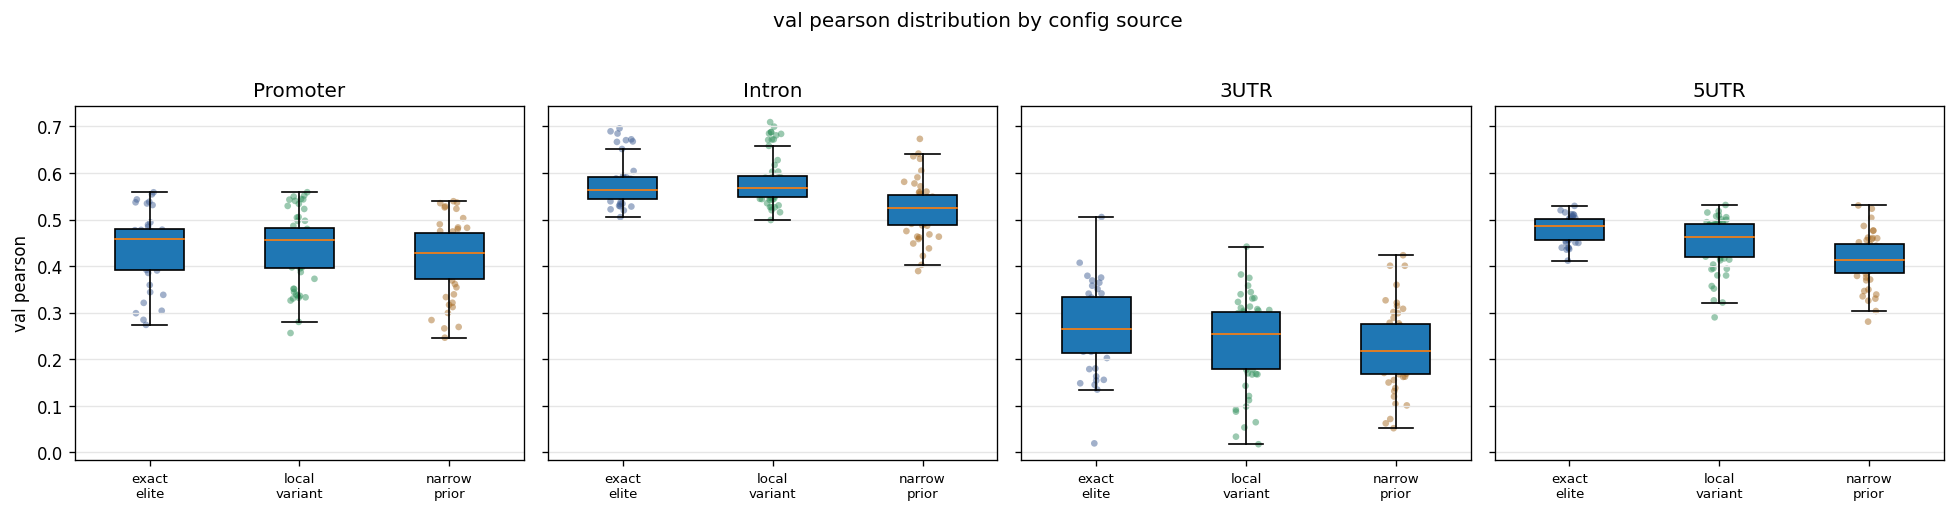

In [57]:
def plot_source_distributions(df, metric='val_pearson'):
    parts = _ordered_parts(df)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.1 * len(parts), 4.1), sharey=True)
    axes = np.atleast_1d(axes)
    rng = np.random.default_rng(17)
    for ax, part in zip(axes, parts):
        sub = df[df['part'].astype(str).eq(part)].copy()
        values = []
        labels = []
        for i, source in enumerate(SOURCE_ORDER, start=1):
            ss = sub[sub['config_source'].astype(str).eq(source)]
            vals = pd.to_numeric(ss[metric], errors='coerce').dropna().to_numpy(dtype=float)
            values.append(vals)
            labels.append(source.replace('_', '\n'))
            if len(vals):
                jitter = rng.normal(0, 0.045, size=len(vals))
                ax.scatter(np.full(len(vals), i) + jitter, vals, s=16, alpha=0.48, color=SOURCE_COLORS[source], edgecolors='none')
        ax.boxplot(values, positions=np.arange(1, len(SOURCE_ORDER) + 1), widths=0.46, patch_artist=True, showfliers=False)
        for patch, source in zip(ax.artists, SOURCE_ORDER):
            patch.set_facecolor(SOURCE_COLORS[source])
            patch.set_alpha(0.24)
        ax.set_xticks(np.arange(1, len(SOURCE_ORDER) + 1))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(part)
        ax.grid(axis='y', color='0.9')
    axes[0].set_ylabel(metric.replace('_', ' '))
    fig.suptitle(f'{metric.replace("_", " ")} distribution by config source', y=1.03)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_source_distributions(outer, metric='val_pearson')


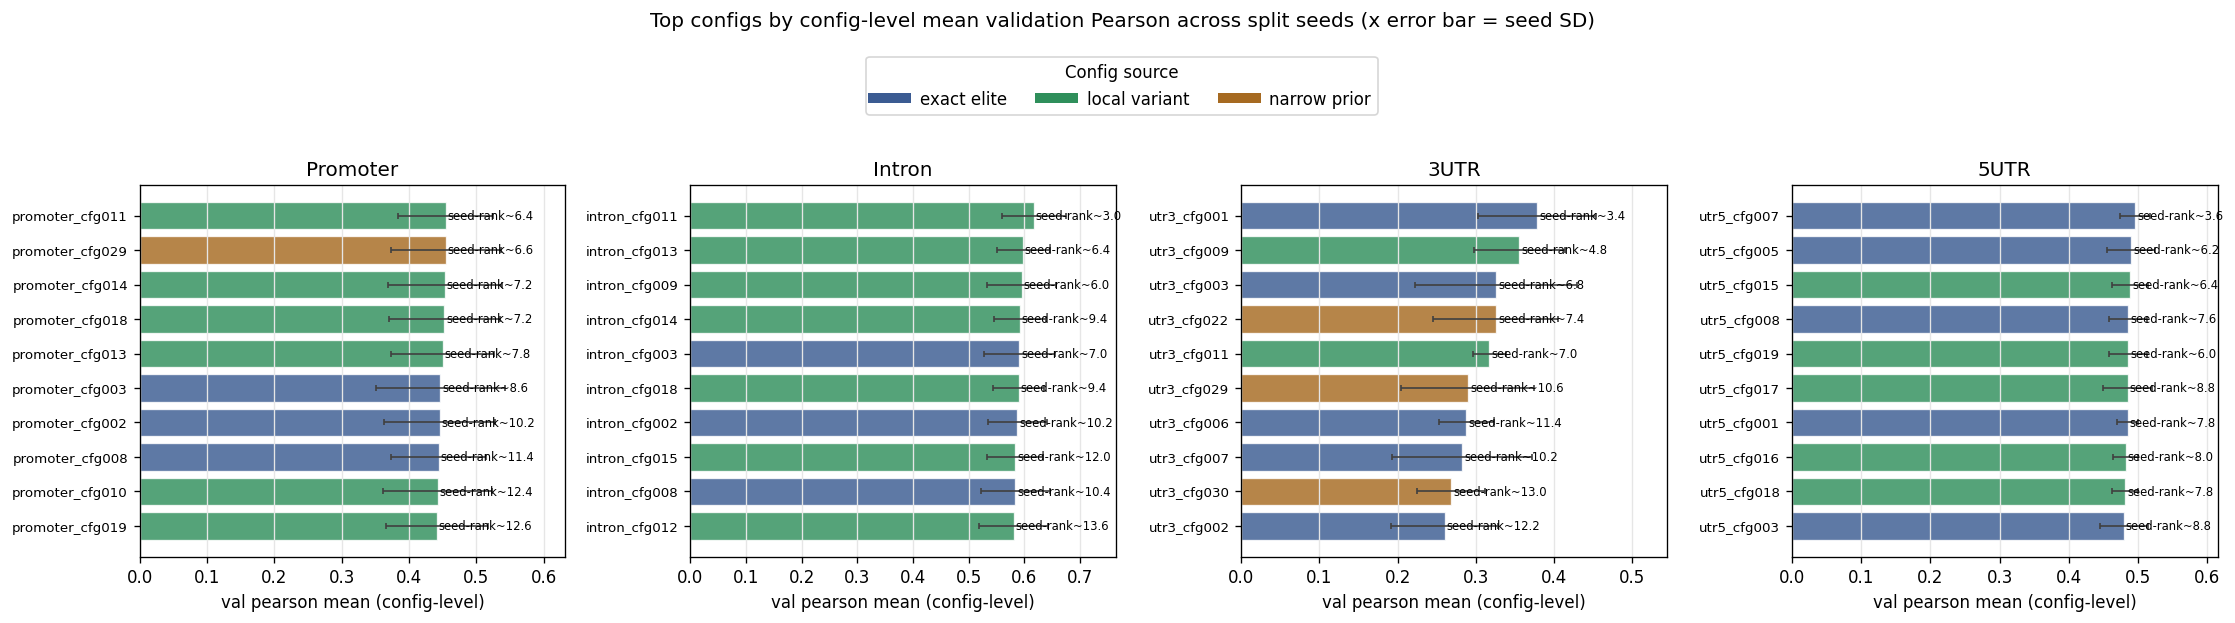

In [58]:
def plot_top_config_errorbars(summary, metric_mean='val_pearson_mean', metric_std='val_pearson_std', top_n=10):
    parts = _ordered_parts(summary)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.7 * len(parts), 5.2), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, part in zip(axes, parts):
        sub = summary[summary['part'].astype(str).eq(part)].sort_values(metric_mean, ascending=False).head(top_n).iloc[::-1]
        y = np.arange(len(sub))
        colors = [SOURCE_COLORS.get(str(src), '0.55') for src in sub['config_source']]
        ax.barh(y, sub[metric_mean], color=colors, alpha=0.82, edgecolor='white', linewidth=0.8)
        ax.errorbar(sub[metric_mean], y, xerr=sub[metric_std], fmt='none', ecolor='0.25', elinewidth=1.0, capsize=2)
        for idx, (_, row) in enumerate(sub.iterrows()):
            ax.text(row[metric_mean] + 0.003, idx, f"seed-rank~{row['mean_seed_rank_val']:.1f}", va='center', fontsize=7)
        xmax = float((sub[metric_mean] + sub[metric_std].fillna(0)).max()) if len(sub) else 1.0
        ax.set_xlim(0, min(1.0, xmax + 0.09))
        ax.set_yticks(y)
        ax.set_yticklabels(sub['config_id'], fontsize=8)
        ax.set_xlabel(metric_mean.replace('_', ' ') + ' (config-level)')
        ax.set_title(part)
        ax.grid(axis='x', color='0.9')
    handles = [plt.Line2D([0], [0], color=SOURCE_COLORS[s], linewidth=6) for s in SOURCE_ORDER]
    labels = [s.replace('_', ' ') for s in SOURCE_ORDER]
    fig.suptitle('Top configs by config-level mean validation Pearson across split seeds (x error bar = seed SD)', y=0.99)
    fig.legend(handles, labels, title='Config source', loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=3, frameon=True)
    fig.tight_layout(rect=[0, 0, 1, 0.84])
    return fig, axes


fig, axes = plot_top_config_errorbars(config_summary, top_n=10)


/home/minhang/miniconda3/envs/boda_env/lib/python3.7/site-packages/ipykernel_launcher.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


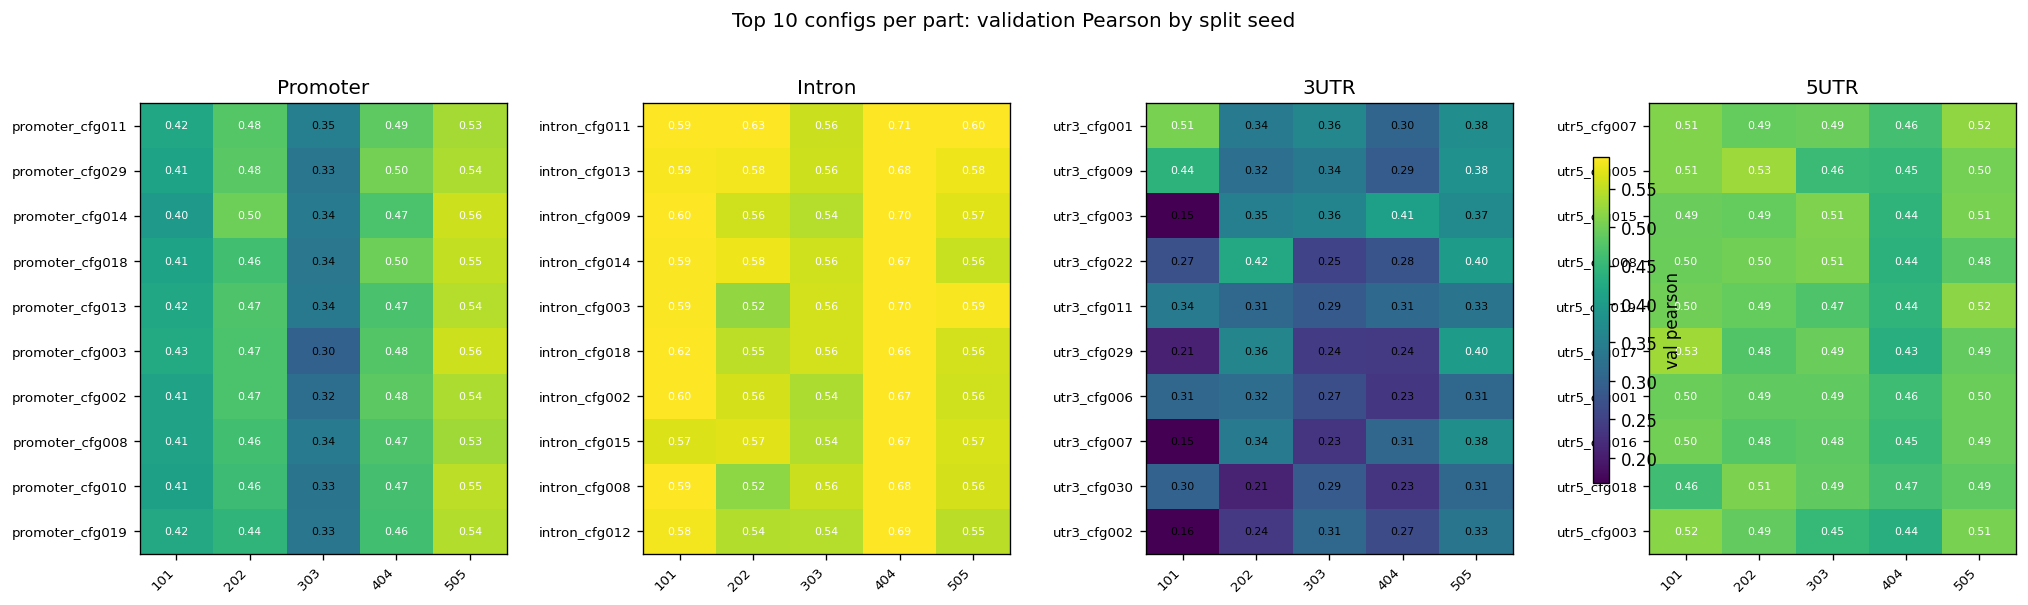

In [59]:
def plot_seed_heatmap(df, summary, metric='val_pearson', top_n=10):
    parts = _ordered_parts(df)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.25 * len(parts), 4.9), sharex=False, sharey=False)
    axes = np.atleast_1d(axes)
    vmin = np.nanpercentile(df[metric], 5)
    vmax = np.nanpercentile(df[metric], 95)
    im = None
    for ax, part in zip(axes, parts):
        top_ids = summary[summary['part'].astype(str).eq(part)].sort_values('rank_val_mean').head(top_n)['config_id'].tolist()
        mat = df[df['part'].astype(str).eq(part) & df['config_id'].isin(top_ids)].pivot_table(
            index='config_id', columns='split_seed', values=metric, aggfunc='first'
        ).reindex(top_ids)
        im = ax.imshow(mat.to_numpy(dtype=float), aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(part)
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_xticklabels([str(int(c)) for c in mat.columns], rotation=45, ha='right', fontsize=8)
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index, fontsize=8)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                value = mat.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=6.5, color='white' if value > (vmin + vmax) / 2 else 'black')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.72, label=metric.replace('_', ' '))
    fig.suptitle(f'Top {top_n} configs per part: validation Pearson by split seed', y=1.02)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_seed_heatmap(outer, config_summary, metric='val_pearson', top_n=10)


,part,split_seed,n_runs,val_pearson_mean,val_pearson_std,test_pearson_mean_diagnostic,train_pearson_mean
0,Promoter,101,30,0.3916,0.0317,0.3360,0.4411
1,Promoter,202,30,0.4578,0.0194,0.3724,0.4854
2,Promoter,303,30,0.3186,0.0318,0.4141,0.4089
3,Promoter,404,30,0.4609,0.0240,0.5250,0.4672
4,Promoter,505,30,0.5231,0.0374,0.4125,0.4418
5,Intron,101,30,0.5572,0.0466,0.6239,0.5241
6,Intron,202,30,0.5402,0.0340,0.6832,0.5682
7,Intron,303,30,0.5241,0.0434,0.6016,0.5331
8,Intron,404,30,0.6487,0.0504,0.4486,0.4989
9,Intron,505,30,0.5439,0.0400,0.6477,0.5495


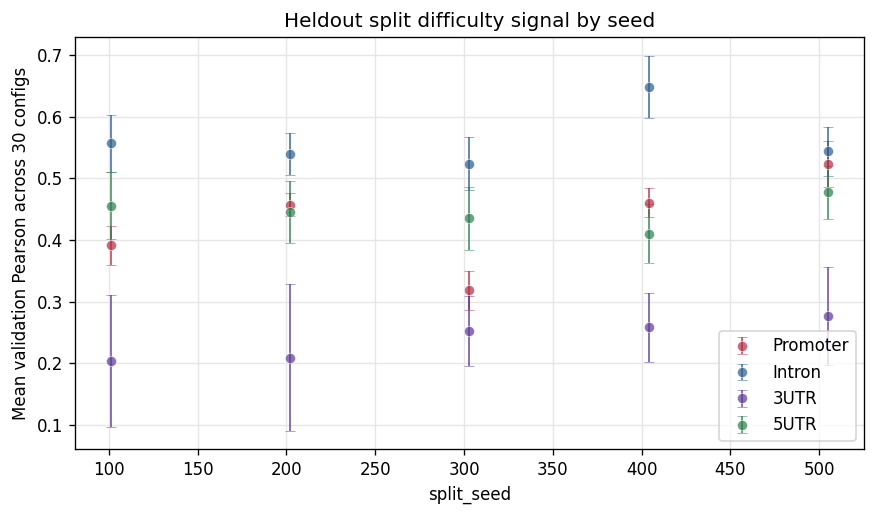

In [60]:
def plot_seed_difficulty(df):
    seed_summary = df.groupby(['part', 'split_seed'], observed=True).agg(
        n_runs=('run_id', 'count'),
        val_pearson_mean=('val_pearson', 'mean'),
        val_pearson_std=('val_pearson', 'std'),
        test_pearson_mean_diagnostic=('test_pearson', 'mean'),
        train_pearson_mean=('train_pearson', 'mean'),
    ).reset_index()
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    for part in PART_ORDER:
        sub = seed_summary[seed_summary['part'].astype(str).eq(part)].sort_values('split_seed')
        if sub.empty:
            continue
        ax.errorbar(
            sub['split_seed'].astype(int), sub['val_pearson_mean'], yerr=sub['val_pearson_std'],
            fmt='o', linestyle='none', markersize=6, capsize=3,
            color=PART_COLORS[part], ecolor=PART_COLORS[part], alpha=0.72,
            elinewidth=1.2, markeredgecolor='white', markeredgewidth=0.4,
            label=part,
        )
    ax.set_xlabel('split_seed')
    ax.set_ylabel('Mean validation Pearson across 30 configs')
    ax.set_title('Heldout split difficulty signal by seed')
    ax.grid(color='0.9')
    ax.legend(frameon=True)
    fig.tight_layout()
    return seed_summary, fig, ax


seed_summary, fig, ax = plot_seed_difficulty(outer)
display(seed_summary.style.format(precision=4))

## Robustness Views Enabled By The Outer-Seed Design

Because the same `config_id` is repeated across all five split seeds, we can ask whether a config is merely lucky on one split or ranks well repeatedly.


In [61]:
robust_cols = [
    'part', 'rank_val_mean', 'rank_val_mean_minus_sd', 'config_id', 'config_source',
    'val_pearson_mean', 'val_pearson_std', 'val_mean_minus_sd', 'val_mean_minus_t95',
    'mean_seed_rank_val', 'worst_seed_rank_val', 'top1_seed_count', 'top3_seed_count', 'top5_seed_count',
    'test_pearson_mean_diagnostic',
]
robust_table = config_summary.sort_values(['part', 'rank_val_mean_minus_sd', 'rank_val_mean']).groupby('part', observed=True).head(5)[robust_cols]
display(robust_table.style.format(precision=4))

per_seed_winners = outer.sort_values(['part', 'split_seed', 'val_pearson'], ascending=[True, True, False]).groupby(['part', 'split_seed'], observed=True).head(1)
display(per_seed_winners[[
    'part', 'split_seed', 'manifest_row', 'config_id', 'config_source', 'run_id', 'val_pearson', 'test_pearson', 'train_pearson', 'best_epoch'
]].style.format(precision=4))


,part,rank_val_mean,rank_val_mean_minus_sd,config_id,config_source,val_pearson_mean,val_pearson_std,val_mean_minus_sd,val_mean_minus_t95,mean_seed_rank_val,worst_seed_rank_val,top1_seed_count,top3_seed_count,top5_seed_count,test_pearson_mean_diagnostic
10,Promoter,1,1,promoter_cfg011,local_variant,0.4547,0.0702,0.3844,0.3675,6.4000,17.0000,0,2,4,0.4408
3,Promoter,22,2,promoter_cfg004,exact_elite,0.4270,0.0528,0.3742,0.3615,18.8000,28.0000,0,1,1,0.4115
12,Promoter,5,3,promoter_cfg013,local_variant,0.4498,0.0759,0.3740,0.3557,7.8000,13.0000,0,0,1,0.4282
7,Promoter,8,4,promoter_cfg008,exact_elite,0.4441,0.0703,0.3738,0.3568,11.4000,18.0000,0,0,0,0.4210
28,Promoter,2,5,promoter_cfg029,narrow_prior,0.4543,0.0817,0.3726,0.3529,6.6000,13.0000,1,2,2,0.4280
40,Intron,1,1,intron_cfg011,local_variant,0.6174,0.0573,0.5601,0.5462,3.0000,7.0000,3,3,4,0.6461
42,Intron,2,2,intron_cfg013,local_variant,0.5982,0.0476,0.5506,0.5391,6.4000,11.0000,0,1,3,0.5986
43,Intron,4,3,intron_cfg014,local_variant,0.5917,0.0469,0.5448,0.5335,9.4000,17.0000,0,1,2,0.5892
47,Intron,6,4,intron_cfg018,local_variant,0.5897,0.0465,0.5432,0.5319,9.4000,19.0000,1,2,2,0.5831
31,Intron,7,5,intron_cfg002,exact_elite,0.5878,0.0528,0.5350,0.5222,10.2000,16.0000,0,1,1,0.5889


,part,split_seed,manifest_row,config_id,config_source,run_id,val_pearson,test_pearson,train_pearson,best_epoch
10,Promoter,101,11,promoter_cfg003,exact_elite,j2exicon,0.4269,0.3460,0.4706,119
66,Promoter,202,67,promoter_cfg014,local_variant,o12o2zm0,0.4971,0.3661,0.6016,123
147,Promoter,303,148,promoter_cfg030,narrow_prior,6s8xafdx,0.3614,0.4439,0.5188,49
143,Promoter,404,144,promoter_cfg029,narrow_prior,9oon8w7r,0.5031,0.5514,0.4897,123
69,Promoter,505,70,promoter_cfg014,local_variant,y0b3zqzj,0.5588,0.4203,0.5605,95
235,Intron,101,236,intron_cfg018,local_variant,dmpkeqxy,0.6173,0.5897,0.6753,179
201,Intron,202,202,intron_cfg011,local_variant,34j3borr,0.6277,0.6612,0.7688,178
162,Intron,303,163,intron_cfg003,exact_elite,hww7moxo,0.5627,0.5954,0.5090,173
203,Intron,404,204,intron_cfg011,local_variant,tz1cd5im,0.7094,0.5678,0.5890,71
204,Intron,505,205,intron_cfg011,local_variant,ocn9pveb,0.6027,0.6688,0.6110,79


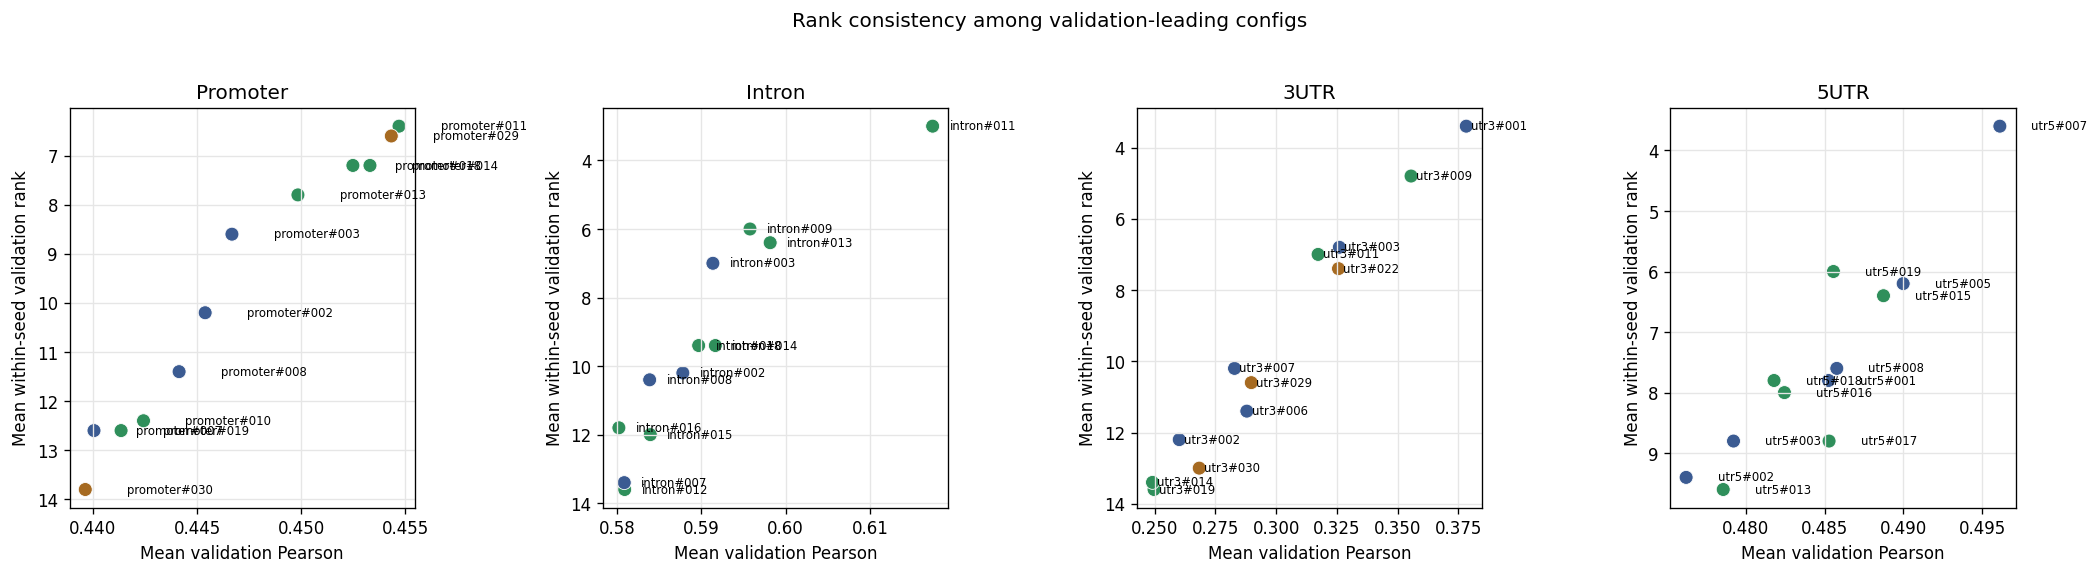

In [62]:
def plot_rank_consistency(summary, top_n=12):
    parts = _ordered_parts(summary)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.4 * len(parts), 4.6), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, part in zip(axes, parts):
        sub = summary[summary['part'].astype(str).eq(part)].sort_values('rank_val_mean').head(top_n)
        colors = [SOURCE_COLORS.get(str(src), '0.55') for src in sub['config_source']]
        ax.scatter(sub['val_pearson_mean'], sub['mean_seed_rank_val'], s=70, color=colors, edgecolors='white', linewidths=0.5)
        for _, row in sub.iterrows():
            ax.text(row['val_pearson_mean'] + 0.002, row['mean_seed_rank_val'], row['config_id'].replace('_cfg', '#'), fontsize=7, va='center')
        ax.invert_yaxis()
        ax.set_xlabel('Mean validation Pearson')
        ax.set_ylabel('Mean within-seed validation rank')
        ax.set_title(part)
        ax.grid(color='0.9')
    fig.suptitle('Rank consistency among validation-leading configs', y=1.03)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_rank_consistency(config_summary, top_n=12)


## Train / Validation / Test Weirdness Flags

If validation or test Pearson is higher than train Pearson, that can be real split difficulty, train-label noise, lower training barcode quality, or scale/COD issues. This section flags those cases without treating them as failures.


In [63]:
for split in ['val', 'test']:
    outer[f'{split}_minus_train_pearson'] = outer[f'{split}_pearson'] - outer['train_pearson']
    outer[f'{split}_minus_train_spearman'] = outer[f'{split}_spearman'] - outer['train_spearman']
    outer[f'{split}_minus_train_cod_r2'] = outer[f'{split}_cod_r2'] - outer['train_cod_r2']
    outer[f'train_minus_{split}_loss'] = outer['train_loss'] - outer[f'{split}_loss']

outer['max_heldout_minus_train_pearson'] = outer[['val_minus_train_pearson', 'test_minus_train_pearson']].max(axis=1)
outer['min_heldout_minus_train_pearson'] = outer[['val_minus_train_pearson', 'test_minus_train_pearson']].min(axis=1)
outer['heldout_pearson_above_train_002'] = outer['max_heldout_minus_train_pearson'] > 0.02
outer['val_pearson_above_train_002'] = outer['val_minus_train_pearson'] > 0.02
outer['test_pearson_above_train_002'] = outer['test_minus_train_pearson'] > 0.02
outer['val_loss_below_train'] = outer['train_minus_val_loss'] > 0
outer['test_loss_below_train'] = outer['train_minus_test_loss'] > 0
outer['both_val_and_test_above_train_pearson'] = outer['val_pearson_above_train_002'] & outer['test_pearson_above_train_002']

weirdness_summary = outer.groupby(['part'], observed=True).agg(
    runs=('run_id', 'count'),
    val_pearson_above_train_n=('val_pearson_above_train_002', 'sum'),
    test_pearson_above_train_n=('test_pearson_above_train_002', 'sum'),
    both_val_test_above_train_n=('both_val_and_test_above_train_pearson', 'sum'),
    val_loss_below_train_n=('val_loss_below_train', 'sum'),
    test_loss_below_train_n=('test_loss_below_train', 'sum'),
    max_heldout_minus_train_pearson=('max_heldout_minus_train_pearson', 'max'),
    median_val_minus_train_pearson=('val_minus_train_pearson', 'median'),
    median_test_minus_train_pearson=('test_minus_train_pearson', 'median'),
    median_train_minus_val_loss=('train_minus_val_loss', 'median'),
    median_train_minus_test_loss=('train_minus_test_loss', 'median'),
).reset_index()
for col in ['val_pearson_above_train_n', 'test_pearson_above_train_n', 'both_val_test_above_train_n', 'val_loss_below_train_n', 'test_loss_below_train_n']:
    weirdness_summary[col.replace('_n', '_frac')] = weirdness_summary[col] / weirdness_summary['runs']

display(weirdness_summary.style.format(precision=4))

top_weird_runs = outer.sort_values('max_heldout_minus_train_pearson', ascending=False).head(24)
display(top_weird_runs[[
    'part', 'manifest_row', 'config_id', 'config_source', 'split_seed', 'run_id',
    'train_pearson', 'val_pearson', 'test_pearson', 'val_minus_train_pearson', 'test_minus_train_pearson',
    'train_cod_r2', 'val_cod_r2', 'test_cod_r2', 'train_loss', 'val_loss', 'test_loss', 'best_epoch'
]].style.format(precision=4))

outer[['planned_run_name', 'run_id', 'part', 'config_id', 'split_seed', 'max_heldout_minus_train_pearson', 'val_pearson_above_train_002', 'test_pearson_above_train_002', 'val_loss_below_train', 'test_loss_below_train']].to_csv(
    ANALYSIS_DIR / 'outer_seed_weirdness_flags.csv', index=False
)


,part,runs,val_pearson_above_train_n,test_pearson_above_train_n,both_val_test_above_train_n,val_loss_below_train_n,test_loss_below_train_n,max_heldout_minus_train_pearson,median_val_minus_train_pearson,median_test_minus_train_pearson,median_train_minus_val_loss,median_train_minus_test_loss,val_pearson_above_train_frac,test_pearson_above_train_frac,both_val_test_above_train_frac,val_loss_below_train_frac,test_loss_below_train_frac
0,Promoter,150,55,48,24,148,117,0.1686,-0.0046,-0.0521,0.3733,0.3127,0.3667,0.3200,0.1600,0.9867,0.7800
1,Intron,150,90,106,61,142,150,0.2483,0.0356,0.0862,0.2922,0.3298,0.6000,0.7067,0.4067,0.9467,1.0000
2,3UTR,150,14,14,3,69,98,0.1586,-0.2446,-0.2364,-0.0477,0.1154,0.0933,0.0933,0.0200,0.4600,0.6533
3,5UTR,150,66,16,10,144,142,0.1460,-0.0056,-0.0387,0.3966,0.3916,0.4400,0.1067,0.0667,0.9600,0.9467


,part,manifest_row,config_id,config_source,split_seed,run_id,train_pearson,val_pearson,test_pearson,val_minus_train_pearson,test_minus_train_pearson,train_cod_r2,val_cod_r2,test_cod_r2,train_loss,val_loss,test_loss,best_epoch
186,Intron,187,intron_cfg008,exact_elite,202,b14ivv2a,0.4457,0.5197,0.6940,0.0740,0.2483,0.1972,0.2539,0.4693,0.8011,0.3988,0.2885,21
161,Intron,162,intron_cfg003,exact_elite,202,xyvnlff2,0.4516,0.5220,0.6981,0.0704,0.2465,0.1997,0.2212,0.4734,0.7988,0.4163,0.2863,42
226,Intron,227,intron_cfg016,local_variant,202,gcjpq8ea,0.4491,0.5269,0.6952,0.0778,0.2461,0.1964,0.2689,0.4636,0.8020,0.3909,0.2916,33
241,Intron,242,intron_cfg019,local_variant,202,n2q1xkqv,0.4554,0.5157,0.7003,0.0603,0.2449,0.2048,0.2491,0.4787,0.7958,0.4014,0.2834,84
176,Intron,177,intron_cfg006,exact_elite,202,z8rc9l03,0.4644,0.5341,0.6984,0.0697,0.2340,0.2097,0.2671,0.4578,0.7881,0.3918,0.2948,29
243,Intron,244,intron_cfg019,local_variant,404,yk3b6sxj,0.4627,0.6851,0.4410,0.2224,-0.0217,0.2136,0.4675,0.1764,0.7862,0.2143,0.5569,87
208,Intron,209,intron_cfg012,local_variant,404,umy5ftfp,0.4762,0.6878,0.4222,0.2117,-0.0540,0.2220,0.4706,0.1577,0.7776,0.2131,0.5695,32
188,Intron,189,intron_cfg008,exact_elite,404,1y7o0j22,0.4747,0.6848,0.4219,0.2101,-0.0528,0.2212,0.4572,0.1362,0.7775,0.2184,0.5841,82
228,Intron,229,intron_cfg016,local_variant,404,xzkzcma3,0.4803,0.6880,0.4246,0.2077,-0.0558,0.2288,0.4708,0.1596,0.7724,0.2130,0.5682,90
193,Intron,194,intron_cfg009,local_variant,404,dit85nw5,0.4935,0.6997,0.4432,0.2061,-0.0503,0.2434,0.4623,0.1606,0.7537,0.2164,0.5676,42


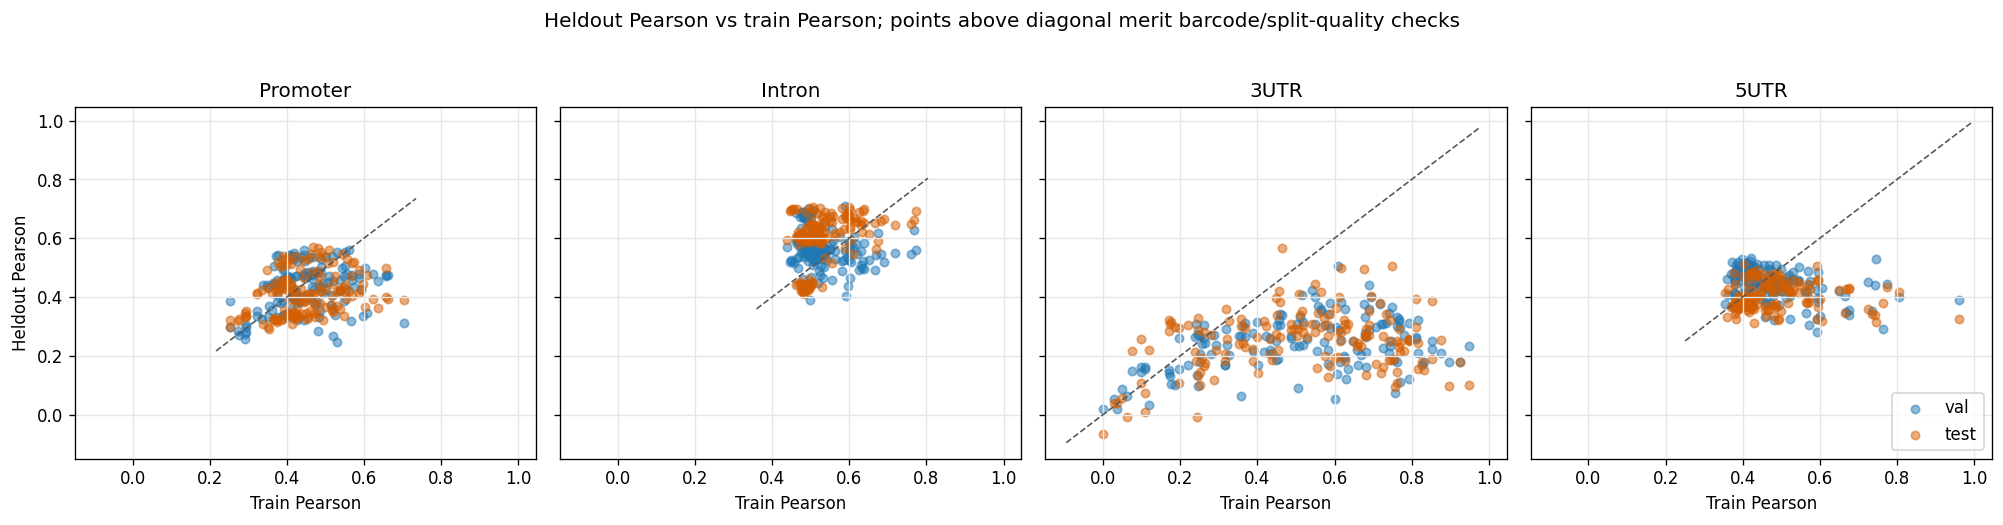

In [64]:
def plot_train_heldout_gap(df):
    parts = _ordered_parts(df)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.2 * len(parts), 4.2), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, part in zip(axes, parts):
        sub = df[df['part'].astype(str).eq(part)]
        ax.scatter(sub['train_pearson'], sub['val_pearson'], s=25, alpha=0.5, color='#1f77b4', label='val')
        ax.scatter(sub['train_pearson'], sub['test_pearson'], s=25, alpha=0.5, color='#d55e00', label='test')
        lo = np.nanmin(sub[['train_pearson', 'val_pearson', 'test_pearson']].to_numpy(dtype=float)) - 0.03
        hi = np.nanmax(sub[['train_pearson', 'val_pearson', 'test_pearson']].to_numpy(dtype=float)) + 0.03
        ax.plot([lo, hi], [lo, hi], color='0.35', linestyle='--', linewidth=1)
        ax.set_title(part)
        ax.set_xlabel('Train Pearson')
        ax.grid(color='0.9')
    axes[0].set_ylabel('Heldout Pearson')
    axes[-1].legend(frameon=True, loc='lower right')
    fig.suptitle('Heldout Pearson vs train Pearson; points above diagonal merit barcode/split-quality checks', y=1.03)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_train_heldout_gap(outer)


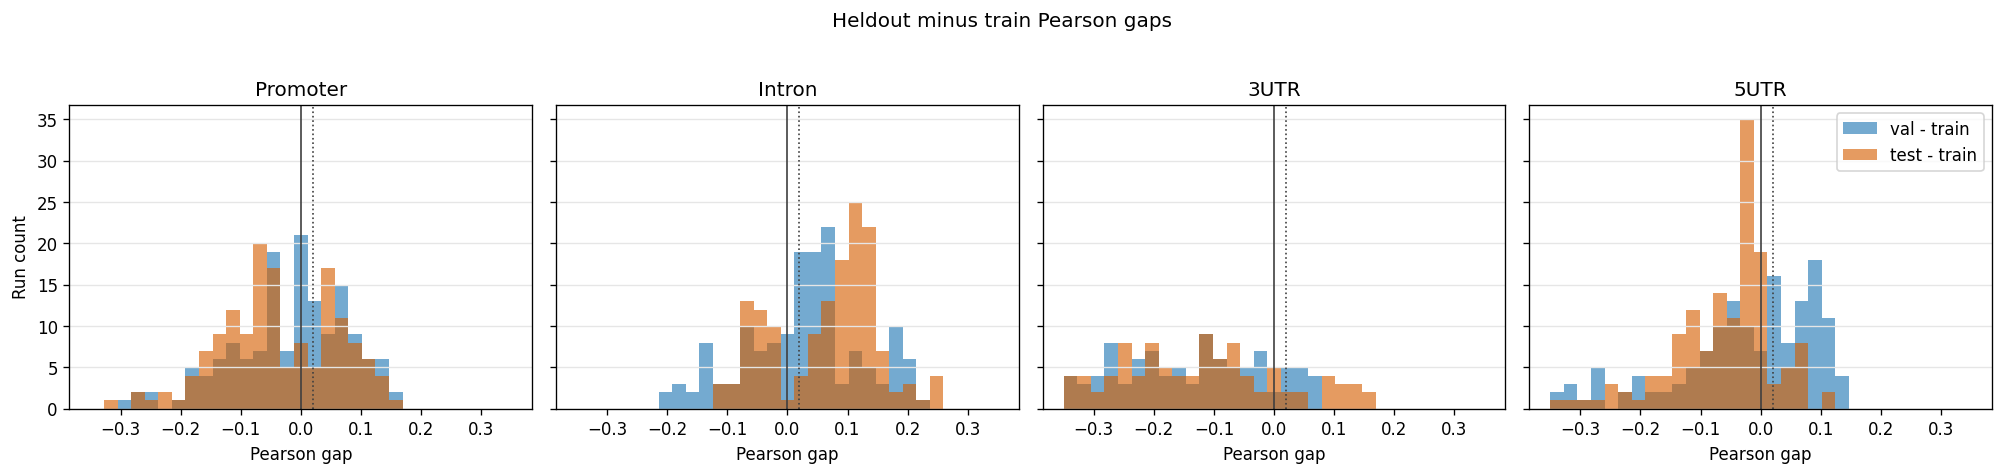

In [65]:
def plot_gap_histograms(df):
    parts = _ordered_parts(df)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.2 * len(parts), 3.8), sharey=True)
    axes = np.atleast_1d(axes)
    bins = np.linspace(-0.35, 0.35, 32)
    for ax, part in zip(axes, parts):
        sub = df[df['part'].astype(str).eq(part)]
        ax.hist(sub['val_minus_train_pearson'].dropna(), bins=bins, alpha=0.62, color='#1f77b4', label='val - train')
        ax.hist(sub['test_minus_train_pearson'].dropna(), bins=bins, alpha=0.62, color='#d55e00', label='test - train')
        ax.axvline(0, color='0.25', linewidth=1)
        ax.axvline(0.02, color='0.25', linewidth=1, linestyle=':')
        ax.set_title(part)
        ax.set_xlabel('Pearson gap')
        ax.grid(axis='y', color='0.9')
    axes[0].set_ylabel('Run count')
    axes[-1].legend(frameon=True)
    fig.suptitle('Heldout minus train Pearson gaps', y=1.03)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_gap_histograms(outer)

## Optional Training Curves From W&B History

The registry contains final restored-checkpoint metrics, but epoch-by-epoch curves require W&B history. Use the export flag below when online/W&B-authenticated. The default selected rows include validation winners and the strongest heldout-above-train flags.


In [66]:
HISTORY_EXPORT_DIR = RUN_REGISTRY / 'wandb_history_exports' / MANIFEST_TAG
HISTORY_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_KEYS = [
    'epoch', 'trainer/global_step',
    'train_pearson', 'val_pearson', 'test_pearson',
    'train_loss', 'val_loss', 'test_loss',
    'train_cod_r2', 'val_cod_r2', 'test_cod_r2',
]


def safe_project_name(project):
    return str(project).replace('/', '__').replace(' ', '_')


def history_path_for_run(run_id, project=None, search_dirs=(HISTORY_EXPORT_DIR, RUN_REGISTRY / 'wandb_history_exports')):
    run_id = str(run_id)
    for directory in search_dirs:
        if not Path(directory).exists():
            continue
        patterns = [f'**/*__{run_id}__history.tsv', f'**/*{run_id}*history.tsv']
        for pattern in patterns:
            matches = sorted(Path(directory).glob(pattern))
            if matches:
                return matches[0]
    return None


def load_history(run_id):
    path = history_path_for_run(run_id)
    if path is None:
        return pd.DataFrame(), None
    hist = pd.read_csv(path, sep='\t', low_memory=False)
    for col in HISTORY_KEYS:
        if col in hist.columns:
            hist[col] = pd.to_numeric(hist[col], errors='coerce')
    if 'epoch' not in hist.columns:
        return pd.DataFrame(), path
    keep = [col for col in HISTORY_KEYS if col in hist.columns]
    hist = hist[keep].dropna(subset=['epoch']).copy()
    if hist.empty:
        return hist, path
    # W&B can have multiple rows per epoch. Keep the last non-null value for each metric.
    def last_valid(s):
        s = s.dropna()
        return s.iloc[-1] if len(s) else np.nan
    agg = {col: last_valid for col in keep if col != 'epoch'}
    hist = hist.groupby('epoch', as_index=False).agg(agg).sort_values('epoch')
    return hist, path


def build_curve_review_run_table(df, summary, n_weird_per_part=2):
    rows = []
    # All five seeds for the validation-selected config in each part.
    winners = summary.loc[summary.groupby('part', observed=True)['rank_val_mean'].idxmin()][['part', 'config_id']]
    rows.append(df.merge(winners, on=['part', 'config_id'], how='inner').assign(curve_reason='validation-selected config: all seeds'))
    # Per-seed winners reveal split-specific training behavior.
    seed_winners = df.sort_values(['part', 'split_seed', 'val_pearson'], ascending=[True, True, False]).groupby(['part', 'split_seed'], observed=True).head(1)
    rows.append(seed_winners.assign(curve_reason='per-seed validation winner'))
    # Most pronounced heldout > train cases.
    weird = df.sort_values(['part', 'max_heldout_minus_train_pearson'], ascending=[True, False]).groupby('part', observed=True).head(n_weird_per_part)
    rows.append(weird.assign(curve_reason='heldout-above-train flag'))
    review = pd.concat(rows, ignore_index=True).drop_duplicates('run_id')
    review['history_path'] = review['run_id'].map(lambda rid: str(history_path_for_run(rid)) if history_path_for_run(rid) else None)
    review['history_found'] = review['history_path'].notna()
    return review.sort_values(['part', 'curve_reason', 'config_id', 'split_seed'])


curve_review_runs = build_curve_review_run_table(outer, config_summary, n_weird_per_part=2)
display(curve_review_runs[[
    'curve_reason', 'part', 'config_id', 'config_source', 'split_seed', 'run_id', 'run_name',
    'train_pearson', 'val_pearson', 'test_pearson', 'max_heldout_minus_train_pearson', 'best_epoch', 'history_found', 'history_path'
]].style.format(precision=4))


,curve_reason,part,config_id,config_source,split_seed,run_id,run_name,train_pearson,val_pearson,test_pearson,max_heldout_minus_train_pearson,best_epoch,history_found,history_path
40,heldout-above-train flag,Promoter,promoter_cfg016,local_variant,505,bhaz0kvk,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg016__seed505,0.3716,0.5402,0.4214,0.1686,76,False,None
41,heldout-above-train flag,Promoter,promoter_cfg019,local_variant,505,2ray4zqx,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg019__seed505,0.3762,0.5428,0.4171,0.1666,83,False,None
20,per-seed validation winner,Promoter,promoter_cfg003,exact_elite,101,j2exicon,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg003__seed101,0.4706,0.4269,0.3460,-0.0437,119,False,None
21,per-seed validation winner,Promoter,promoter_cfg014,local_variant,202,o12o2zm0,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg014__seed202,0.6016,0.4971,0.3661,-0.1045,123,False,None
24,per-seed validation winner,Promoter,promoter_cfg014,local_variant,505,y0b3zqzj,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg014__seed505,0.5605,0.5588,0.4203,-0.0017,95,False,None
23,per-seed validation winner,Promoter,promoter_cfg029,narrow_prior,404,9oon8w7r,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg029__seed404,0.4897,0.5031,0.5514,0.0618,123,False,None
22,per-seed validation winner,Promoter,promoter_cfg030,narrow_prior,303,6s8xafdx,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg030__seed303,0.5188,0.3614,0.4439,-0.0749,49,False,None
0,validation-selected config: all seeds,Promoter,promoter_cfg011,local_variant,101,2yd05lwa,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg011__seed101,0.5001,0.4222,0.3648,-0.0779,154,False,None
1,validation-selected config: all seeds,Promoter,promoter_cfg011,local_variant,202,fnv71sg9,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg011__seed202,0.4741,0.4800,0.3747,0.0059,128,False,None
2,validation-selected config: all seeds,Promoter,promoter_cfg011,local_variant,303,k1xypw0c,lib1_outer_seed_prior_no_rc_june2026__promoter__promoter_cfg011__seed303,0.4868,0.3510,0.4708,-0.0160,141,False,None


In [67]:
RUN_WANDB_HISTORY_EXPORT = False
MAX_HISTORY_EXPORT_RUNS = None  # Use a small integer for a quick pilot, or None for all curve_review_runs.


def export_wandb_histories(run_table, keys=HISTORY_KEYS, overwrite=False, max_runs=None):
    import wandb
    api = wandb.Api()
    rows = []
    todo = run_table.drop_duplicates('run_id').copy()
    if max_runs is not None:
        todo = todo.head(int(max_runs))
    for _, row in todo.iterrows():
        run_id = str(row['run_id'])
        entity = str(row['wandb_entity'])
        project = str(row['logger_project'])
        out_path = HISTORY_EXPORT_DIR / f'{safe_project_name(project)}__{run_id}__history.tsv'
        if out_path.exists() and not overwrite:
            rows.append({'run_id': run_id, 'history_path': str(out_path), 'status': 'exists'})
            continue
        wandb_path = f'{entity}/{project}/{run_id}'
        print(f'Fetching {wandb_path}')
        run = api.run(wandb_path)
        hist = run.history(keys=list(keys), pandas=True)
        hist.to_csv(out_path, sep='\t', index=False)
        rows.append({'run_id': run_id, 'history_path': str(out_path), 'status': 'written', 'n_rows': len(hist)})
    return pd.DataFrame(rows)


if RUN_WANDB_HISTORY_EXPORT:
    history_export_audit = export_wandb_histories(curve_review_runs, overwrite=False, max_runs=MAX_HISTORY_EXPORT_RUNS)
    display(history_export_audit)
else:
    print('W&B history export skipped. Set RUN_WANDB_HISTORY_EXPORT=True after confirming W&B auth/network.')


W&B history export skipped. Set RUN_WANDB_HISTORY_EXPORT=True after confirming W&B auth/network.


In [68]:
def plot_learning_curve_grid(run_table, metrics=('train_pearson', 'val_pearson', 'test_pearson'), max_runs=16, ncols=4):
    available = run_table.copy()
    available['history_path'] = available['run_id'].map(lambda rid: str(history_path_for_run(rid)) if history_path_for_run(rid) else None)
    available = available[available['history_path'].notna()].drop_duplicates('run_id').head(max_runs)
    if available.empty:
        print(f'No exported histories found under {HISTORY_EXPORT_DIR}. Run the W&B export cell first.')
        return None, None
    n = len(available)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.25 * nrows), squeeze=False)
    colors = {'train_pearson': '#4d4d4d', 'val_pearson': '#1f77b4', 'test_pearson': '#d55e00', 'train_loss': '#4d4d4d', 'val_loss': '#1f77b4', 'test_loss': '#d55e00'}
    labels = {m: m.replace('_', ' ') for m in colors}
    for ax, (_, row) in zip(axes.flat, available.iterrows()):
        hist, path = load_history(row['run_id'])
        if hist.empty:
            ax.set_axis_off()
            ax.set_title(f"{row['run_id']}\nempty history")
            continue
        for metric in metrics:
            if metric not in hist.columns:
                continue
            series = hist[['epoch', metric]].dropna()
            if series.empty:
                continue
            ax.plot(series['epoch'], series[metric], color=colors.get(metric, '0.4'), linewidth=1.8, label=labels.get(metric, metric))
            ax.scatter(series['epoch'], series[metric], color=colors.get(metric, '0.4'), s=8, alpha=0.25)
        if pd.notna(row.get('best_epoch')):
            ax.axvline(float(row['best_epoch']), color='black', linestyle='--', linewidth=1, alpha=0.75)
        ax.set_title(f"{row['part']} {row['config_id']} seed={int(row['split_seed'])}\n{row['run_id']} | {row.get('curve_reason', '')}", fontsize=8)
        ax.set_xlabel('epoch')
        ax.grid(axis='y', color='0.9')
    for ax in axes.flat[n:]:
        ax.set_axis_off()
    handles = [plt.Line2D([0], [0], color=colors[m], linewidth=2) for m in metrics if m in colors]
    leg_labels = [labels.get(m, m) for m in metrics if m in colors]
    handles.append(plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1))
    leg_labels.append('best epoch')
    fig.legend(handles, leg_labels, loc='upper center', ncol=min(5, len(leg_labels)), frameon=True)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig, axes


fig, axes = plot_learning_curve_grid(curve_review_runs, metrics=('train_pearson', 'val_pearson', 'test_pearson'), max_runs=16, ncols=4)


No exported histories found under /home/minhang/synBio_AL/boda2_EU/src/learn/run_registry/wandb_history_exports/lib1_outer_seed_prior_no_rc_june2026. Run the W&B export cell first.


## Split Reconstruction And Barcode Composition

This reconstructs the train/val/test row assignments from the manifest data parameters. It is useful for checking whether train has more low-barcode/noisier labels than validation/test, which can make heldout Pearson look better than train Pearson.


In [69]:
RUN_SPLIT_RECONSTRUCTION = True


def sep_value(value):
    return '\t' if value in {'tab', '\\t', '\t'} else value


def part_params_from_manifest(manifest_df):
    keys = [
        'part', 'part_slug', 'datafile_path', 'sep', 'sequence_column', 'target_column', 'barcode_column',
        'test_min_barcodes', 'train_min_barcodes', 'val_frac_within_hq', 'test_frac_within_hq',
        'val_size_within_hq', 'test_size_within_hq', 'train_size_frac', 'train_sampling_mode',
    ]
    rows = []
    for part, sub in manifest_df.groupby('part', observed=True):
        row = sub.iloc[0][keys].to_dict()
        row['split_seed_values'] = sorted(map(int, sub['split_seed'].dropna().unique()))
        rows.append(row)
    return pd.DataFrame(rows).sort_values('part')


part_params = part_params_from_manifest(manifest)
display(part_params)


def load_part_frame(params):
    path = Path(str(params['datafile_path']))
    if not path.is_absolute():
        path = LEARN / path
    seq_col = params['sequence_column']
    target_col = params['target_column']
    barcode_col = params['barcode_column']
    df = pd.read_csv(path, sep=sep_value(params.get('sep', '\t')), low_memory=False).copy()
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df[barcode_col] = pd.to_numeric(df[barcode_col], errors='coerce')
    df = df.loc[df[seq_col].notna() & df[barcode_col].notna() & np.isfinite(df[target_col])].reset_index(drop=True)
    df['row_id'] = np.arange(len(df))
    return df


def assign_lib1_splits(df, params, split_seed):
    seq_col = params['sequence_column']
    target_col = params['target_column']
    barcode_col = params['barcode_column']
    test_min = int(params.get('test_min_barcodes') or 4)
    train_min = int(params.get('train_min_barcodes') or 1)
    val_frac = float(params.get('val_frac_within_hq') or 0.2)
    test_frac = float(params.get('test_frac_within_hq') or 0.2)
    val_size = params.get('val_size_within_hq')
    test_size = params.get('test_size_within_hq')
    train_size_frac = float(params.get('train_size_frac') or 1.0)
    train_sampling_mode = params.get('train_sampling_mode') or 'random'

    hq_df = df.loc[df[barcode_col] >= test_min].copy()
    rng = np.random.default_rng(int(split_seed))
    perm = rng.permutation(hq_df.index.to_numpy())
    n_hq = len(perm)
    n_test = int(test_size) if pd.notna(test_size) else max(1, int(round(n_hq * test_frac)))
    n_val = int(val_size) if pd.notna(val_size) else max(1, int(round(n_hq * val_frac)))
    if n_test + n_val >= n_hq:
        if pd.notna(test_size) or pd.notna(val_size):
            raise ValueError(f'Requested val/test sizes ({n_val}/{n_test}) exhaust HQ rows ({n_hq})')
        n_test = max(1, n_hq // 5)
        n_val = max(1, n_hq // 5)

    test_idx = set(perm[:n_test].tolist())
    val_idx = set(perm[n_test:n_test + n_val].tolist())
    used_idx = test_idx | val_idx

    split_frames = []
    for split_name, idx in [('test', test_idx), ('val', val_idx)]:
        frame = df.loc[df.index.isin(idx), ['row_id', seq_col, target_col, barcode_col]].copy()
        frame['split'] = split_name
        split_frames.append(frame)

    rest = df.loc[~df.index.isin(used_idx)].copy().reset_index(drop=True)
    eligible = rest.loc[rest[barcode_col] >= train_min].copy().reset_index(drop=True)
    if train_size_frac >= 1.0:
        train = eligible.copy()
    else:
        train_n = min(len(eligible), max(32, int(round(len(eligible) * train_size_frac))))
        train = eligible.sample(n=train_n, random_state=int(split_seed), replace=False).reset_index(drop=True)
    train = train[['row_id', seq_col, target_col, barcode_col]].copy()
    train['split'] = 'train'
    split_frames.append(train)

    assigned = pd.concat(split_frames, ignore_index=True)
    assigned = assigned.rename(columns={seq_col: 'sequence', target_col: 'target', barcode_col: 'n_barcodes'})
    assigned['split_seed'] = int(split_seed)
    assigned['test_min_barcodes'] = test_min
    assigned['train_min_barcodes'] = train_min
    assigned['barcode_quality'] = np.where(assigned['n_barcodes'] >= test_min, 'hq', 'low_barcode')
    assigned['part'] = params['part']
    assigned['part_slug'] = params['part_slug']
    return assigned


def row_id_hash(values):
    text = ','.join(map(str, sorted(map(int, values))))
    return hashlib.sha1(text.encode('utf-8')).hexdigest()[:16]


if RUN_SPLIT_RECONSTRUCTION:
    split_frames = []
    for _, params in part_params.iterrows():
        frame = load_part_frame(params)
        for seed in params['split_seed_values']:
            split_frames.append(assign_lib1_splits(frame, params, int(seed)))
    split_assignments = pd.concat(split_frames, ignore_index=True)
    split_assignments['part'] = pd.Categorical(split_assignments['part'].astype(str), categories=PART_ORDER, ordered=True)
    split_assignments['split'] = pd.Categorical(split_assignments['split'], categories=SPLIT_ORDER, ordered=True)
    split_summary = split_assignments.groupby(['part', 'split_seed', 'split'], observed=True).agg(
        n_rows=('row_id', 'nunique'),
        n_hq=('barcode_quality', lambda s: int((s == 'hq').sum())),
        n_low_barcode=('barcode_quality', lambda s: int((s == 'low_barcode').sum())),
        median_n_barcodes=('n_barcodes', 'median'),
        mean_n_barcodes=('n_barcodes', 'mean'),
        target_median=('target', 'median'),
        target_mean=('target', 'mean'),
        target_std=('target', 'std'),
        target_iqr=('target', lambda s: s.quantile(0.75) - s.quantile(0.25)),
        row_id_hash=('row_id', row_id_hash),
    ).reset_index()
    display(split_summary.style.format(precision=4))
    split_assignments.to_csv(ANALYSIS_DIR / 'outer_seed_split_assignments_reconstructed.csv', index=False)
    split_summary.to_csv(ANALYSIS_DIR / 'outer_seed_split_summary_reconstructed.csv', index=False)
else:
    print('Split reconstruction skipped.')


,part,part_slug,datafile_path,sep,sequence_column,target_column,barcode_column,test_min_barcodes,train_min_barcodes,val_frac_within_hq,test_frac_within_hq,val_size_within_hq,test_size_within_hq,train_size_frac,train_sampling_mode,split_seed_values
0,3UTR,utr3,/home/minhang/synBio_AL/boda2_EU/src/learn/derived_data/utr3/bashor_in_house/lib1_threeprime_modal100_fastqs1_5__learn_ready.tsv,tab,ThreePrime,log2_RNA_DNA,n_barcodes,8,1,0.2500,0.2500,NaN,NaN,1.0,random,"[101, 202, 303, 404, 505]"
1,5UTR,utr5,/home/minhang/synBio_AL/boda2_EU/src/learn/derived_data/utr5/bashor_in_house/lib1_fiveprime_modal50_fastqs1_5__learn_ready.tsv,tab,FivePrime,log2_RNA_DNA,n_barcodes,8,1,0.2000,0.2000,250.0,250.0,1.0,random,"[101, 202, 303, 404, 505]"
2,Intron,intron,/home/minhang/synBio_AL/boda2_EU/src/learn/derived_data/introns/bashor_in_house/lib1_intron_modal80_fastqs1_5__learn_ready.tsv,tab,Intron,log2_RNA_DNA,n_barcodes,8,1,0.2000,0.2000,250.0,250.0,1.0,random,"[101, 202, 303, 404, 505]"
3,Promoter,promoter,/home/minhang/synBio_AL/boda2_EU/src/learn/derived_data/promoter/bashor_in_house/lib1_promoter_allvalid_fastqs1_5__learn_ready.tsv,tab,Promoter,log2_RNA_DNA,n_barcodes,8,1,0.1295,0.1295,250.0,250.0,1.0,random,"[101, 202, 303, 404, 505]"


,part,split_seed,split,n_rows,n_hq,n_low_barcode,median_n_barcodes,mean_n_barcodes,target_median,target_mean,target_std,target_iqr,row_id_hash
0,Promoter,101,train,7393,1431,5962,4.0000,5.3938,1.8699,1.8818,0.6456,0.7236,f1461239f0aa1c8a
1,Promoter,101,val,250,250,0,10.0000,11.7160,1.8166,1.8061,0.4572,0.5284,2f3282cb01a55ffb
2,Promoter,101,test,250,250,0,11.0000,12.0400,1.8363,1.8028,0.6424,0.5919,74a40b0d1518bd38
3,Promoter,202,train,7393,1431,5962,4.0000,5.3947,1.8657,1.8769,0.6504,0.7245,6bd6095d6e339736
4,Promoter,202,val,250,250,0,10.0000,11.7480,1.8926,1.8912,0.4735,0.5496,c145977153312d6c
5,Promoter,202,test,250,250,0,11.0000,11.9800,1.8278,1.8607,0.4697,0.5214,62391cadf19c2b2e
6,Promoter,303,train,7393,1431,5962,4.0000,5.3958,1.8718,1.8807,0.6485,0.7219,8c155bfccbe60a1f
7,Promoter,303,val,250,250,0,11.0000,12.0080,1.8031,1.7950,0.5510,0.5225,dab6528d3b79670c
8,Promoter,303,test,250,250,0,10.0000,11.6880,1.8406,1.8449,0.4545,0.5433,313bc314ea42820e
9,Promoter,404,train,7393,1431,5962,4.0000,5.3863,1.8683,1.8775,0.6508,0.7227,d6933eb32000a3b3


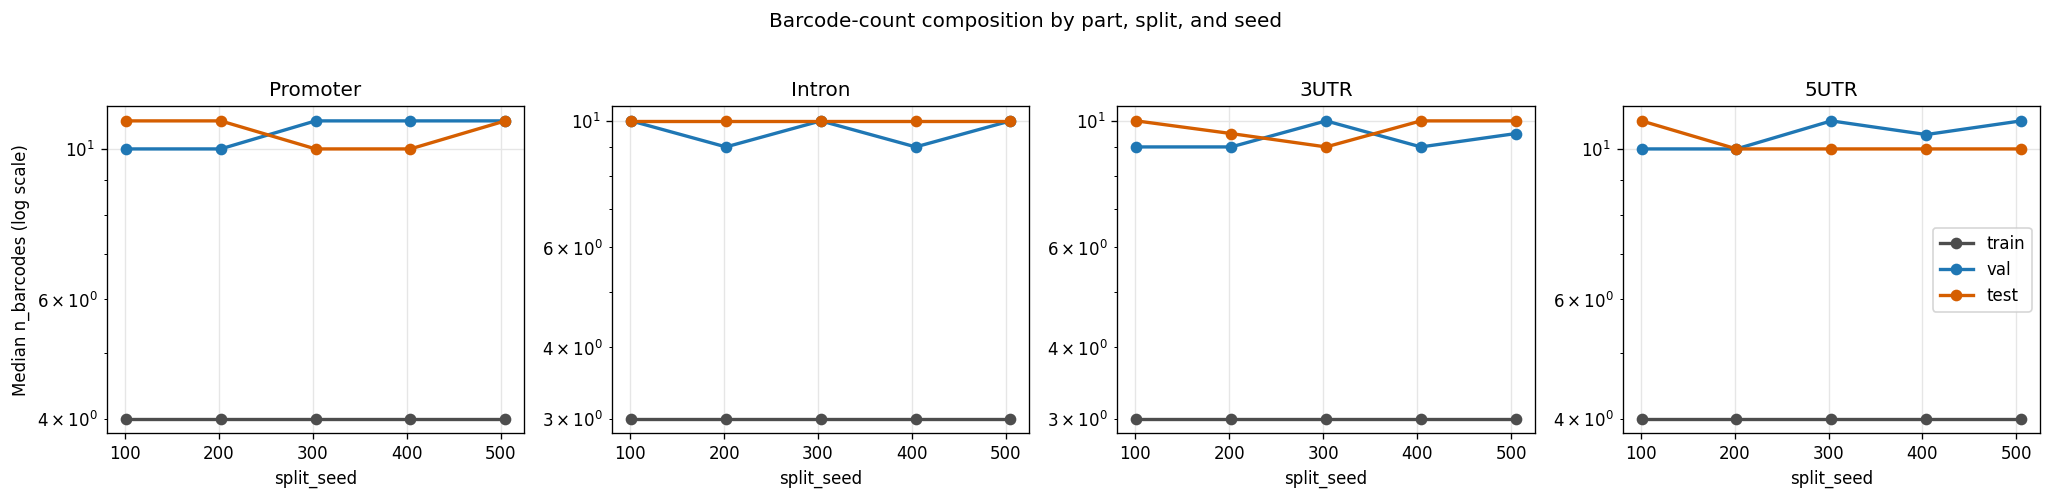

In [70]:
def plot_split_barcode_summary(split_summary):
    parts = _ordered_parts(split_summary)
    fig, axes = plt.subplots(1, len(parts), figsize=(4.3 * len(parts), 4.0), sharey=False)
    axes = np.atleast_1d(axes)
    split_colors = {'train': '#4d4d4d', 'val': '#1f77b4', 'test': '#d55e00'}
    for ax, part in zip(axes, parts):
        sub = split_summary[split_summary['part'].astype(str).eq(part)]
        for split in SPLIT_ORDER:
            ss = sub[sub['split'].astype(str).eq(split)].sort_values('split_seed')
            if ss.empty:
                continue
            ax.plot(ss['split_seed'].astype(int), ss['median_n_barcodes'], marker='o', linewidth=2, color=split_colors[split], label=split)
        ax.set_yscale('log')
        ax.set_title(part)
        ax.set_xlabel('split_seed')
        ax.grid(color='0.9')
    axes[0].set_ylabel('Median n_barcodes (log scale)')
    axes[-1].legend(frameon=True)
    fig.suptitle('Barcode-count composition by part, split, and seed', y=1.03)
    fig.tight_layout()
    return fig, axes


if RUN_SPLIT_RECONSTRUCTION:
    fig, axes = plot_split_barcode_summary(split_summary)


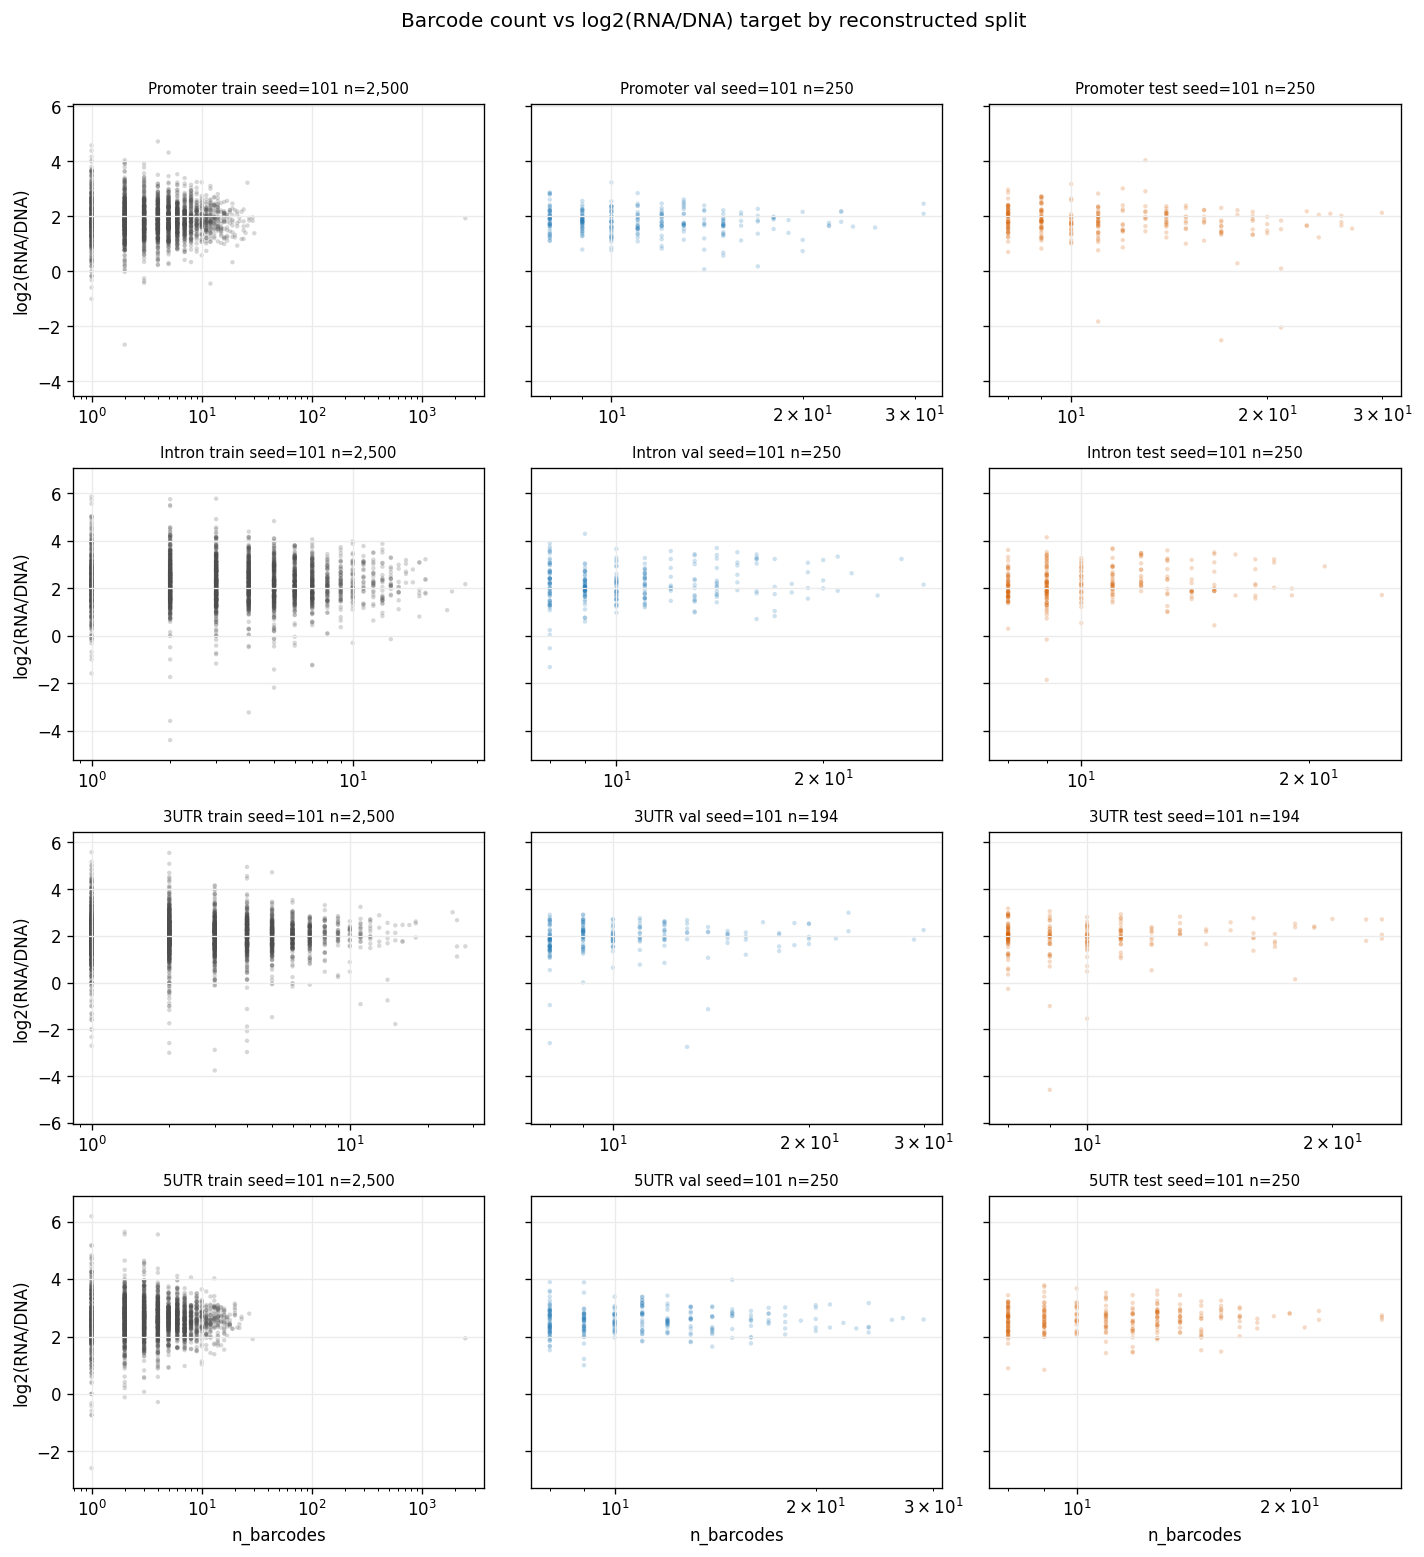

In [71]:
def plot_barcode_vs_target_by_split(assignments, representative_seed=101, max_points_per_panel=2500, target_label='log2(RNA/DNA)'):
    plot_df = assignments[assignments['split_seed'].eq(int(representative_seed))].copy()
    parts = _ordered_parts(plot_df)
    fig, axes = plt.subplots(len(parts), 3, figsize=(12.0, 3.2 * len(parts)), sharex=False, sharey='row')
    axes = np.atleast_2d(axes)
    split_colors = {'train': '#4d4d4d', 'val': '#1f77b4', 'test': '#d55e00'}
    for r, part in enumerate(parts):
        part_all = plot_df[plot_df['part'].astype(str).eq(part)]
        y_all = part_all['target'].to_numpy(dtype=float)
        y_all = y_all[np.isfinite(y_all)]
        if len(y_all):
            ymin, ymax = float(np.nanmin(y_all)), float(np.nanmax(y_all))
            ypad = max(0.08 * (ymax - ymin), 0.10)
            ylim = (ymin - ypad, ymax + ypad)
        else:
            ylim = None
        for c, split in enumerate(SPLIT_ORDER):
            ax = axes[r, c]
            sub = plot_df[plot_df['part'].astype(str).eq(part) & plot_df['split'].astype(str).eq(split)].copy()
            if len(sub) > max_points_per_panel:
                sub = sub.sample(n=max_points_per_panel, random_state=23)
            ax.scatter(sub['n_barcodes'], sub['target'], s=7, alpha=0.22, color=split_colors[split], edgecolors='none')
            ax.set_xscale('log')
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.set_title(f'{part} {split} seed={representative_seed} n={len(sub):,}', fontsize=9)
            ax.grid(color='0.92')
            if r == len(parts) - 1:
                ax.set_xlabel('n_barcodes')
            if c == 0:
                ax.set_ylabel(target_label)
    fig.suptitle('Barcode count vs log2(RNA/DNA) target by reconstructed split', y=1.01)
    fig.tight_layout()
    return fig, axes


if RUN_SPLIT_RECONSTRUCTION:
    fig, axes = plot_barcode_vs_target_by_split(split_assignments, representative_seed=101, max_points_per_panel=2500)


## Optional Checkpoint-Level Barcode Residual Diagnostics

Set `RUN_HEAVY_CHECKPOINT_EVAL=True` to load selected checkpoints, re-evaluate `train_all`, `train_hq`, `train_low_barcode`, `val`, and `test`, and then use the residual-vs-barcode plots below. This is the most direct check for the hypothesis that train metrics are depressed by lower-barcode/noisier labels.


In [72]:
RUN_HEAVY_CHECKPOINT_EVAL = True
# Conservative default: one validation-selected representative per part, chosen as the seed with the highest validation Pearson
# within the validation-selected config. Add weirdness-flagged rows if desired.
EVAL_RUN_TABLE = (
    outer.merge(winner_by_val[['part', 'config_id']], on=['part', 'config_id'], how='inner')
    .sort_values(['part', 'val_pearson'], ascending=[True, False])
    .groupby('part', observed=True)
    .head(1)
    .copy()
)

def locate_artifact(row):
    path = row.get('artifact_path')
    if isinstance(path, str) and path and Path(path).exists() and str(path).endswith('.tar.gz'):
        return Path(path)
    run_id = str(row.get('run_id'))
    candidates = sorted((LEARN / 'local_artifacts' / MANIFEST_TAG).glob(f'**/*{run_id}*.tar.gz'))
    if candidates:
        return candidates[0]
    project = str(row.get('logger_project'))
    candidates = sorted((LEARN / 'local_artifacts').glob(f'**/*{project}*{run_id}*.tar.gz'))
    if candidates:
        return candidates[0]
    return None

artifact_audit = EVAL_RUN_TABLE.copy()
artifact_audit['artifact_path_resolved'] = artifact_audit.apply(locate_artifact, axis=1).map(lambda p: str(p) if p else None)
artifact_audit['artifact_found'] = artifact_audit['artifact_path_resolved'].notna()
display(artifact_audit[['part', 'config_id', 'split_seed', 'run_id', 'val_pearson', 'test_pearson', 'artifact_found', 'artifact_path_resolved']].style.format(precision=4))


,part,config_id,split_seed,run_id,val_pearson,test_pearson,artifact_found,artifact_path_resolved
4,Promoter,promoter_cfg011,505,d87f80v2,0.5339,0.4278,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/lib1_outer_seed_prior_no_rc_june2026/promoter/promoter_cfg011/split_seed_505/model_artifacts__promoter__bashor_in_house__lib1_allvalid__outer_seed_prior_no_rc__promoter_bassetvl__d87f80v2__20260615_002659.tar.gz
8,Intron,intron_cfg011,404,tz1cd5im,0.7094,0.5678,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/lib1_outer_seed_prior_no_rc_june2026/intron/intron_cfg011/split_seed_404/model_artifacts__introns__bashor_in_house__lib1_intron_modal80__outer_seed_prior_no_rc__resnet1d__tz1cd5im__20260615_031912.tar.gz
10,3UTR,utr3_cfg001,101,5rz4g6wb,0.5054,0.1948,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/lib1_outer_seed_prior_no_rc_june2026/utr3/utr3_cfg001/split_seed_101/model_artifacts__utr3__bashor_in_house__threeprime_modal100__outer_seed_prior_no_rc__resnet1d_fp32__5rz4g6wb__20260615_045237.tar.gz
19,5UTR,utr5_cfg007,505,mp9wc6xz,0.5200,0.3608,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/lib1_outer_seed_prior_no_rc_june2026/utr5/utr5_cfg007/split_seed_505/model_artifacts__utr5__bashor_in_house__fiveprime_modal50__outer_seed_prior_no_rc__resnet1d_fp32__mp9wc6xz__20260615_080947.tar.gz


In [73]:
def pearson_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) < 3 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def spearman_np(y_true, y_pred):
    return pd.Series(y_true).corr(pd.Series(y_pred), method='spearman')


def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.sqrt(np.mean((y_true[ok] - y_pred[ok]) ** 2))) if ok.sum() else np.nan


def cod_r2_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) < 2:
        return np.nan
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / denom)


def regression_metrics(frame, true_col='true_raw', pred_col='pred_raw'):
    y = frame[true_col].to_numpy(dtype=float)
    p = frame[pred_col].to_numpy(dtype=float)
    residual = y - p
    return {
        'n': int(np.isfinite(y).sum()),
        'pearson': pearson_np(y, p),
        'spearman': spearman_np(y, p),
        'rmse': rmse_np(y, p),
        'cod_r2': cod_r2_np(y, p),
        'mse': float(np.nanmean(residual ** 2)),
        'mae': float(np.nanmean(np.abs(residual))),
        'residual_mean': float(np.nanmean(residual)),
        'abs_residual_median': float(np.nanmedian(np.abs(residual))),
    }


def load_model_and_data_from_artifact(artifact_path, device=None):
    import torch
    import boda

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    artifact_path = Path(artifact_path)
    with tempfile.TemporaryDirectory() as tmpdir:
        with tarfile.open(artifact_path, 'r:gz') as tar:
            tar.extractall(tmpdir)
        ckpt_path = Path(tmpdir) / 'artifacts' / 'torch_checkpoint.pt'
        ckpt = torch.load(ckpt_path, map_location='cpu')

    data_cls = getattr(boda.data, ckpt['data_module'])
    model_cls = getattr(boda.model, ckpt['model_module'])
    data = data_cls(**vars(ckpt['data_hparams']))
    data.setup()
    model = model_cls(**vars(ckpt['model_hparams']))
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval().to(device)
    return model, data, ckpt


def predict_frame(model, data, frame, batch_size=512, device=None):
    import torch
    from torch.utils.data import DataLoader

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    frame = frame.copy()
    if 'row_id' not in frame.columns:
        frame['row_id'] = frame.index.to_numpy()
    barcode_col = getattr(data, 'barcode_column', 'n_barcodes')
    ds = data._df_to_dataset(frame.copy(), training=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    preds, labels = [], []
    model.eval().to(device)
    with torch.no_grad():
        for batch in loader:
            x, y = batch[:2]
            yhat = model(x.to(device)).detach().cpu()
            if yhat.ndim == 2 and yhat.shape[1] == 1:
                yhat = yhat[:, 0]
            if y.ndim == 2 and y.shape[1] == 1:
                y = y[:, 0]
            preds.append(yhat)
            labels.append(y.detach().cpu())
    pred_scaled = torch.cat(preds).numpy()
    true_scaled = torch.cat(labels).numpy()
    out = frame.reset_index(drop=True).copy()
    out['pred_scaled'] = pred_scaled
    out['true_scaled'] = true_scaled
    if getattr(data, 'normalize', True):
        out['pred_raw'] = pred_scaled * data.target_std + data.target_mean
        out['true_raw'] = true_scaled * data.target_std + data.target_mean
    else:
        out['pred_raw'] = pred_scaled
        out['true_raw'] = true_scaled
    if barcode_col in out.columns and 'n_barcodes' not in out.columns:
        out['n_barcodes'] = out[barcode_col]
    out['residual_raw'] = out['true_raw'] - out['pred_raw']
    out['abs_residual_raw'] = out['residual_raw'].abs()
    return out


def evaluate_quality_splits(row, device=None):
    artifact = locate_artifact(row)
    if artifact is None:
        raise FileNotFoundError(f"No artifact found for {row['run_id']}")
    model, data, ckpt = load_model_and_data_from_artifact(artifact, device=device)
    barcode_col = data.barcode_column
    test_min = data.test_min_barcodes
    frames = {
        'train_all': data.df_train,
        'train_hq': data.df_train[data.df_train[barcode_col] >= test_min].copy(),
        'train_low_barcode': data.df_train[data.df_train[barcode_col] < test_min].copy(),
        'val': data.df_val,
        'test': data.df_test,
    }
    pred_parts = []
    metric_rows = []
    for eval_split, frame in frames.items():
        pred = predict_frame(model, data, frame, device=device)
        pred['eval_split'] = eval_split
        pred['run_id'] = row['run_id']
        pred['run_name'] = row['run_name']
        pred['part'] = row['part']
        pred['config_id'] = row['config_id']
        pred['config_source'] = row['config_source']
        pred['split_seed'] = int(row['split_seed']) if pd.notna(row['split_seed']) else np.nan
        pred_parts.append(pred)
        metric_rows.append({
            'run_id': row['run_id'],
            'run_name': row['run_name'],
            'part': row['part'],
            'config_id': row['config_id'],
            'config_source': row['config_source'],
            'split_seed': int(row['split_seed']) if pd.notna(row['split_seed']) else np.nan,
            'eval_split': eval_split,
            **regression_metrics(pred),
        })
    return pd.DataFrame(metric_rows), pd.concat(pred_parts, ignore_index=True)


if RUN_HEAVY_CHECKPOINT_EVAL:
    metric_tables = []
    prediction_tables = []
    for _, row in EVAL_RUN_TABLE.iterrows():
        print(f"Evaluating {row['part']} {row['config_id']} seed={row['split_seed']} run={row['run_id']}")
        metrics, preds = evaluate_quality_splits(row)
        metric_tables.append(metrics)
        prediction_tables.append(preds)
    checkpoint_eval_metrics = pd.concat(metric_tables, ignore_index=True)
    checkpoint_eval_predictions = pd.concat(prediction_tables, ignore_index=True)
    checkpoint_eval_metrics.to_csv(ANALYSIS_DIR / 'outer_seed_checkpoint_quality_split_metrics.csv', index=False)
    checkpoint_eval_predictions.to_parquet(ANALYSIS_DIR / 'outer_seed_checkpoint_quality_split_predictions.parquet', index=False)
    display(checkpoint_eval_metrics.sort_values(['part', 'config_id', 'split_seed', 'eval_split']).style.format(precision=4))
else:
    print('Heavy checkpoint evaluation skipped. Set RUN_HEAVY_CHECKPOINT_EVAL=True when ready.')


Evaluating Promoter promoter_cfg011 seed=505 run=d87f80v2


Evaluating Intron intron_cfg011 seed=404 run=tz1cd5im
Evaluating 3UTR utr3_cfg001 seed=101 run=5rz4g6wb
Evaluating 5UTR utr5_cfg007 seed=505 run=mp9wc6xz


,run_id,run_name,part,config_id,config_source,split_seed,eval_split,n,pearson,spearman,rmse,cod_r2,mse,mae,residual_mean,abs_residual_median
14,5rz4g6wb,lib1_outer_seed_prior_no_rc_june2026__utr3__utr3_cfg001__seed101,3UTR,utr3_cfg001,exact_elite,101,test,194,0.1948,0.1557,0.8394,-0.0894,0.7046,0.5251,-0.2846,0.3748
10,5rz4g6wb,lib1_outer_seed_prior_no_rc_june2026__utr3__utr3_cfg001__seed101,3UTR,utr3_cfg001,exact_elite,101,train_all,6457,0.6083,0.4461,0.7733,0.2515,0.5980,0.5690,-0.1675,0.4248
11,5rz4g6wb,lib1_outer_seed_prior_no_rc_june2026__utr3__utr3_cfg001__seed101,3UTR,utr3_cfg001,exact_elite,101,train_hq,387,0.6787,0.3999,0.5395,0.3244,0.2911,0.3775,-0.1868,0.3086
12,5rz4g6wb,lib1_outer_seed_prior_no_rc_june2026__utr3__utr3_cfg001__seed101,3UTR,utr3_cfg001,exact_elite,101,train_low_barcode,6070,0.6067,0.4494,0.7858,0.2490,0.6175,0.5812,-0.1662,0.4380
13,5rz4g6wb,lib1_outer_seed_prior_no_rc_june2026__utr3__utr3_cfg001__seed101,3UTR,utr3_cfg001,exact_elite,101,val,194,0.5781,0.1428,0.6900,0.1304,0.4761,0.4806,-0.2888,0.3611
19,mp9wc6xz,lib1_outer_seed_prior_no_rc_june2026__utr5__utr5_cfg007__seed505,5UTR,utr5_cfg007,exact_elite,505,test,250,0.3608,0.4060,0.4363,0.1164,0.1904,0.3334,0.0059,0.2848
15,mp9wc6xz,lib1_outer_seed_prior_no_rc_june2026__utr5__utr5_cfg007__seed505,5UTR,utr5_cfg007,exact_elite,505,train_all,7831,0.3875,0.4186,0.6019,0.1478,0.3622,0.4355,0.0022,0.3225
16,mp9wc6xz,lib1_outer_seed_prior_no_rc_june2026__utr5__utr5_cfg007__seed505,5UTR,utr5_cfg007,exact_elite,505,train_hq,1297,0.5073,0.5076,0.3848,0.2559,0.1480,0.2922,-0.0163,0.2339
17,mp9wc6xz,lib1_outer_seed_prior_no_rc_june2026__utr5__utr5_cfg007__seed505,5UTR,utr5_cfg007,exact_elite,505,train_low_barcode,6534,0.3762,0.4048,0.6362,0.1386,0.4048,0.4639,0.0059,0.3456
18,mp9wc6xz,lib1_outer_seed_prior_no_rc_june2026__utr5__utr5_cfg007__seed505,5UTR,utr5_cfg007,exact_elite,505,val,250,0.5284,0.5535,0.3983,0.2659,0.1586,0.2926,-0.0432,0.2072


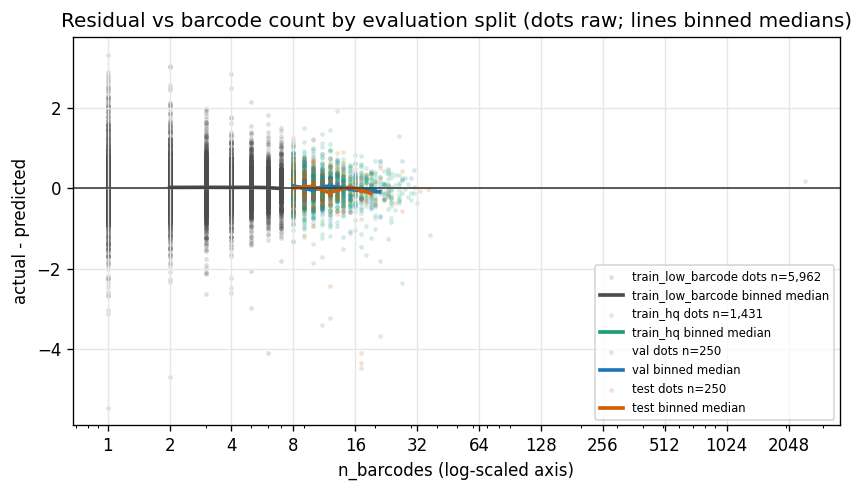

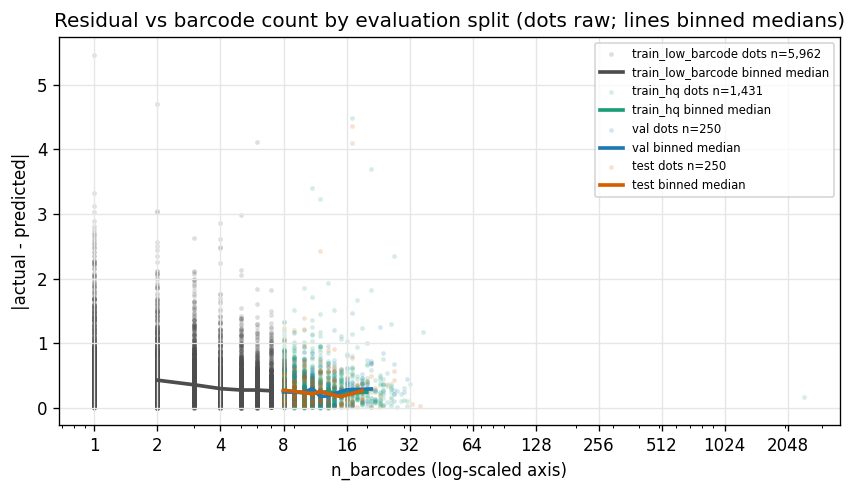

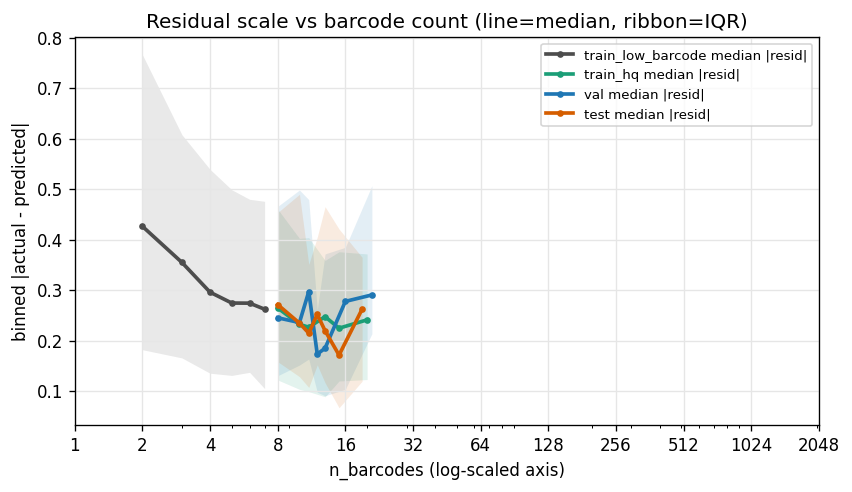

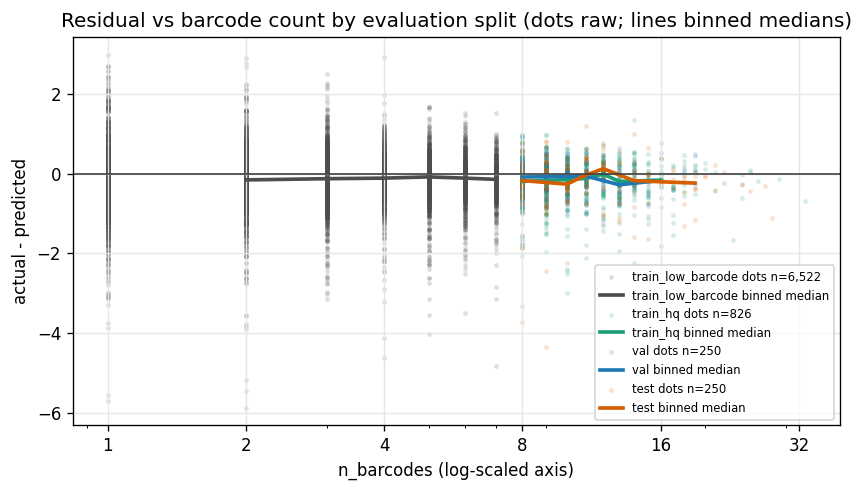

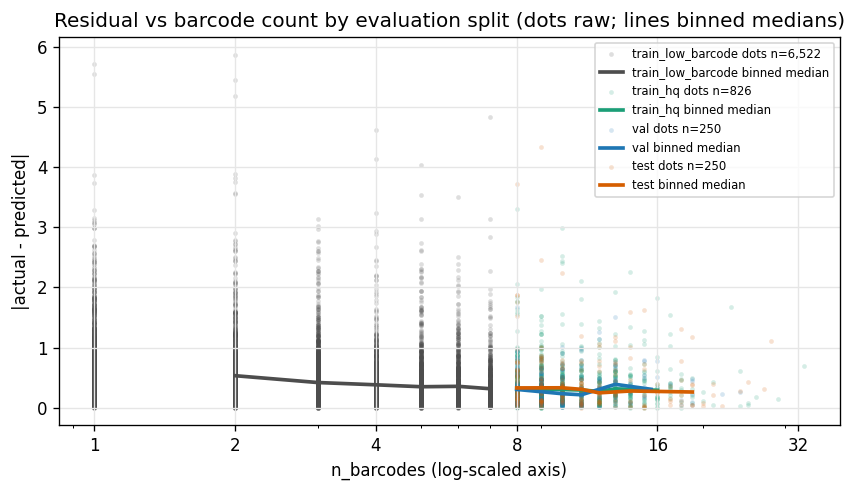

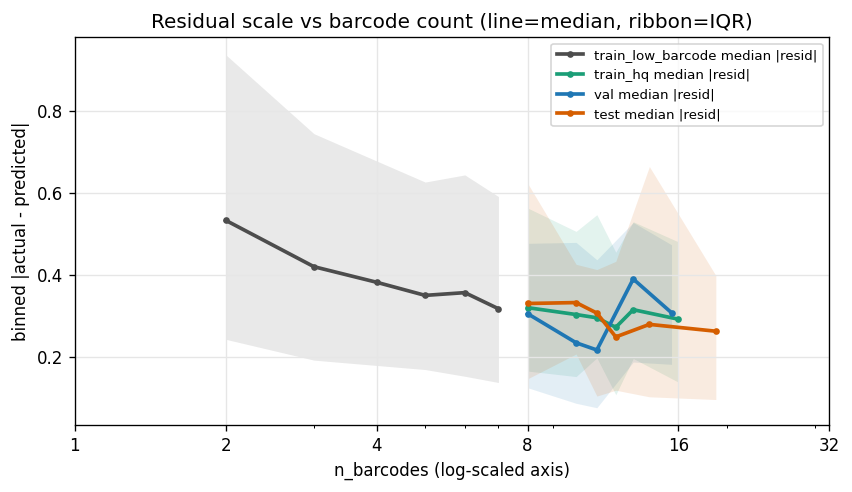

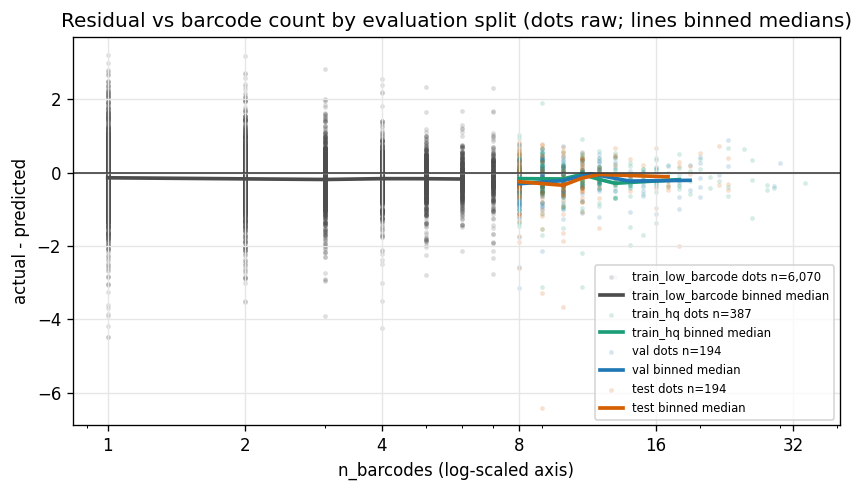

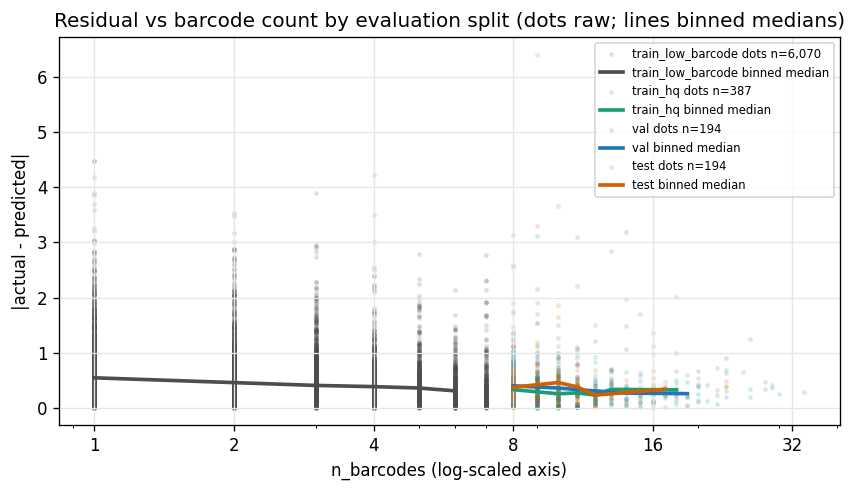

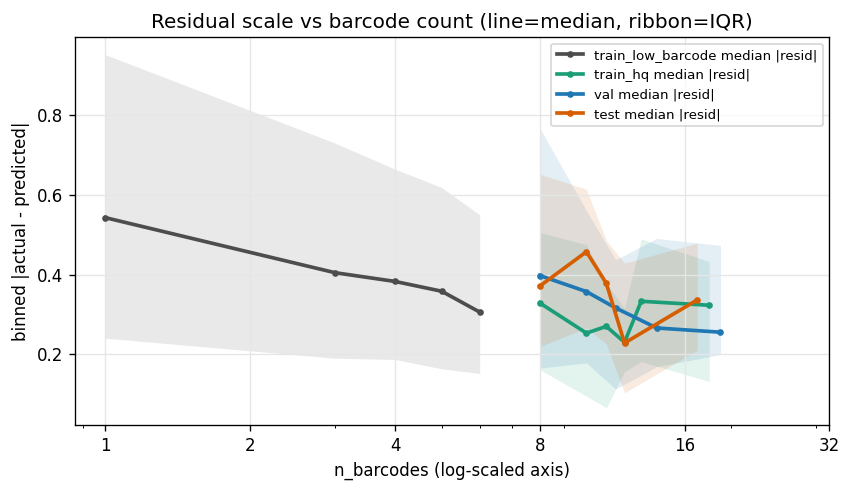

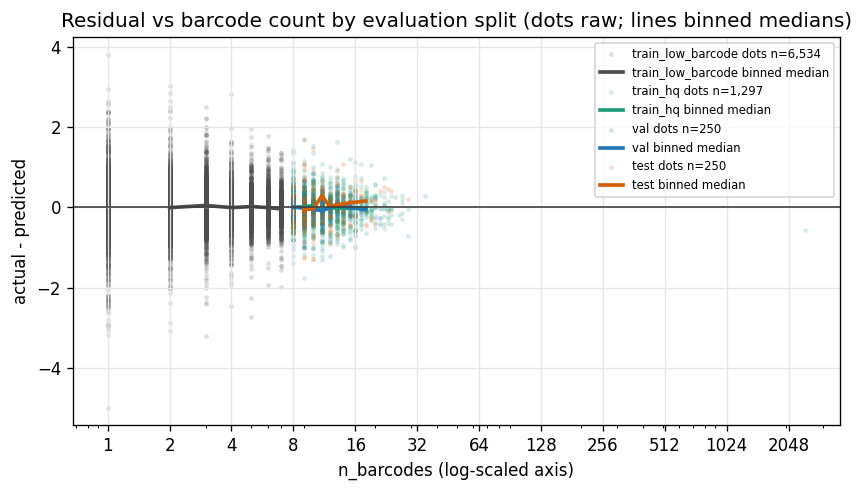

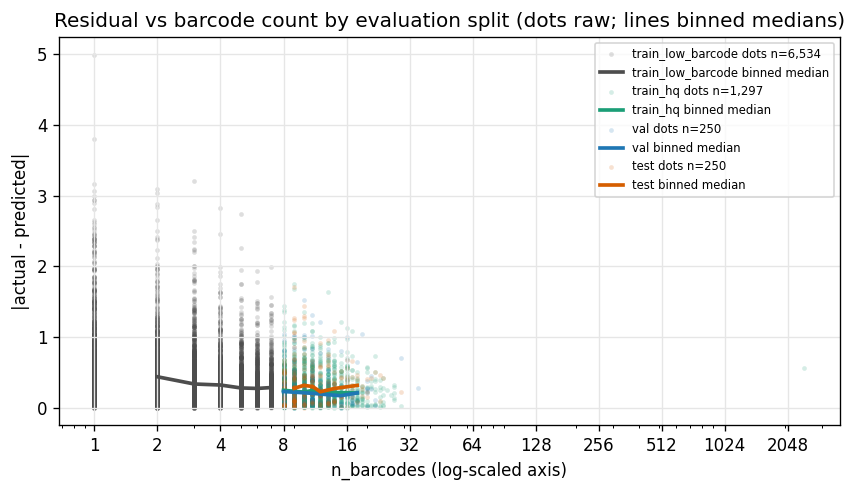

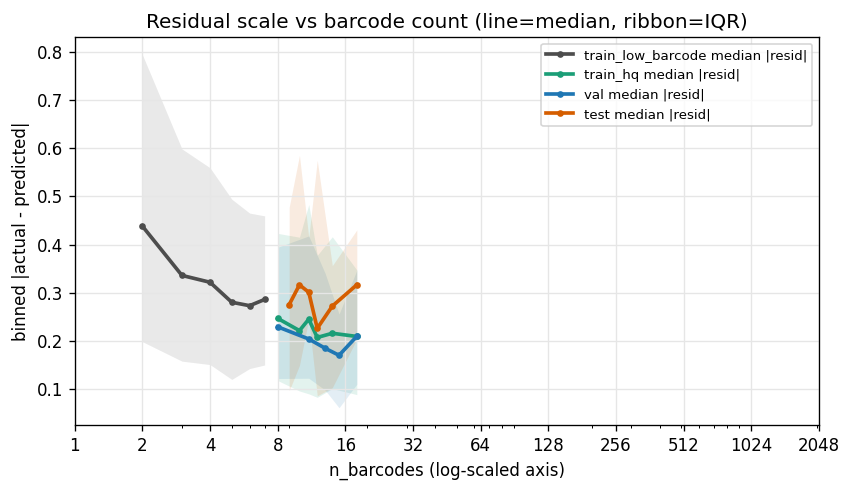

In [74]:
def _binned_barcode_summary(barcodes, y, n_bins=8):
    barcodes = np.asarray(barcodes, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(barcodes) & np.isfinite(y) & (barcodes > 0)
    barcodes, y = barcodes[ok], y[ok]
    if len(barcodes) < 30:
        return pd.DataFrame()
    # Bin in log space so low barcode counts are not compressed by a few high-count outliers,
    # but plot the bin centers as actual barcode counts.
    x_for_bins = np.log1p(barcodes)
    n_bins = min(int(n_bins), len(np.unique(x_for_bins)))
    if n_bins < 2:
        return pd.DataFrame()
    bins = np.quantile(x_for_bins, np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)
    if len(bins) <= 2:
        return pd.DataFrame()
    idx = np.digitize(x_for_bins, bins[1:-1], right=True)
    return pd.DataFrame({'bin': idx, 'barcode': barcodes, 'y': y}).groupby('bin', as_index=False).agg(
        barcode=('barcode', 'median'),
        y_median=('y', 'median'),
        y_q25=('y', lambda s: np.quantile(s, 0.25)),
        y_q75=('y', lambda s: np.quantile(s, 0.75)),
        n=('y', 'size'),
    )


def _format_barcode_xaxis(ax, values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        ax.set_xlabel('n_barcodes')
        return
    xmin, xmax = float(np.nanmin(values)), float(np.nanmax(values))
    ax.set_xscale('log')
    base_ticks = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192], dtype=float)
    ticks = base_ticks[(base_ticks >= max(1, xmin * 0.9)) & (base_ticks <= xmax * 1.1)]
    if len(ticks) < 3:
        unique_vals = np.unique(values.astype(int))
        ticks = unique_vals[:12] if len(unique_vals) > 12 else unique_vals
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) if float(t).is_integer() else f'{t:g}' for t in ticks])
    ax.set_xlabel('n_barcodes (log-scaled axis)')


def plot_residual_vs_barcode_combined(predictions, run_id=None, absolute=False, add_binned_median=True):
    """Plot raw residual dots plus optional binned median lines.

    With signed residuals, the binned line is a bias diagnostic: median(actual - predicted)
    at each barcode-count bin. For label-noise/residual-scale diagnosis, use absolute=True
    or plot_binned_residual_scale_vs_barcode below.
    """
    plot_df = predictions.copy()
    if run_id is not None:
        plot_df = plot_df[plot_df['run_id'].astype(str).eq(str(run_id))]
    if plot_df.empty:
        raise ValueError('No predictions to plot')
    y_col = 'abs_residual_raw' if absolute else 'residual_raw'
    ylabel = '|actual - predicted|' if absolute else 'actual - predicted'
    split_order = ['train_low_barcode', 'train_hq', 'val', 'test']
    colors = {'train_low_barcode': '#4d4d4d', 'train_hq': '#1b9e77', 'val': '#1f77b4', 'test': '#d55e00'}
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    all_barcodes = []
    for split in split_order:
        sub = plot_df[plot_df['eval_split'].eq(split)].copy()
        if sub.empty:
            continue
        x = sub['n_barcodes'].to_numpy(dtype=float)
        y = sub[y_col].to_numpy(dtype=float)
        ok = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x, y = x[ok], y[ok]
        all_barcodes.extend(x.tolist())
        ax.scatter(x, y, s=8, alpha=0.18, linewidth=0, label=f'{split} dots n={len(x):,}', color=colors.get(split, '0.5'))
        if add_binned_median:
            med = _binned_barcode_summary(x, y)
            if not med.empty:
                ax.plot(med['barcode'], med['y_median'], color=colors.get(split, '0.5'), linewidth=2.2, label=f'{split} binned median')
    if not absolute:
        ax.axhline(0, color='0.25', linewidth=1)
    _format_barcode_xaxis(ax, all_barcodes)
    ax.set_ylabel(ylabel)
    line_note = 'dots raw; lines binned medians' if add_binned_median else 'raw dots only'
    ax.set_title(f'Residual vs barcode count by evaluation split ({line_note})')
    ax.legend(frameon=True, fontsize=7, loc='best', ncol=1)
    ax.grid(color='0.9')
    fig.tight_layout()
    return fig, ax


def plot_binned_residual_scale_vs_barcode(predictions, run_id=None, n_bins=8):
    """Plot binned median absolute residual with an IQR ribbon."""
    plot_df = predictions.copy()
    if run_id is not None:
        plot_df = plot_df[plot_df['run_id'].astype(str).eq(str(run_id))]
    if plot_df.empty:
        raise ValueError('No predictions to plot')
    split_order = ['train_low_barcode', 'train_hq', 'val', 'test']
    colors = {'train_low_barcode': '#4d4d4d', 'train_hq': '#1b9e77', 'val': '#1f77b4', 'test': '#d55e00'}
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    all_barcodes = []
    for split in split_order:
        sub = plot_df[plot_df['eval_split'].eq(split)].copy()
        if sub.empty:
            continue
        x = sub['n_barcodes'].to_numpy(dtype=float)
        y = sub['abs_residual_raw'].to_numpy(dtype=float)
        all_barcodes.extend(x[np.isfinite(x) & (x > 0)].tolist())
        binned = _binned_barcode_summary(x, y, n_bins=n_bins)
        if binned.empty:
            continue
        color = colors.get(split, '0.5')
        ax.plot(binned['barcode'], binned['y_median'], color=color, linewidth=2.2, marker='o', markersize=3, label=f'{split} median |resid|')
        ax.fill_between(binned['barcode'], binned['y_q25'], binned['y_q75'], color=color, alpha=0.12, linewidth=0)
    _format_barcode_xaxis(ax, all_barcodes)
    ax.set_ylabel('binned |actual - predicted|')
    ax.set_title('Residual scale vs barcode count (line=median, ribbon=IQR)')
    ax.legend(frameon=True, fontsize=8, loc='best')
    ax.grid(color='0.9')
    fig.tight_layout()
    return fig, ax


if 'checkpoint_eval_predictions' in globals():
    for run_id in checkpoint_eval_predictions['run_id'].drop_duplicates().head(4):
        fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id=run_id, absolute=False)
        fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id=run_id, absolute=True)
        fig, ax = plot_binned_residual_scale_vs_barcode(checkpoint_eval_predictions, run_id=run_id)
else:
    print('Residual plots skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')


## Optional Paired Bootstrap After Checkpoint Evaluation

Use this only for predictions on shared row IDs, typically two configs evaluated on the same `part` and `split_seed`. Validation remains the selection metric; paired bootstrap is for evidence strength and diagnostics.


In [75]:
def metric_value(y_true, y_pred, metric):
    if metric == 'pearson':
        return pearson_np(y_true, y_pred)
    if metric == 'spearman':
        return spearman_np(y_true, y_pred)
    if metric == 'rmse':
        return rmse_np(y_true, y_pred)
    if metric == 'cod_r2':
        return cod_r2_np(y_true, y_pred)
    raise ValueError(metric)


def paired_bootstrap_delta(frame_left, frame_right, metrics=('pearson', 'spearman', 'rmse', 'cod_r2'), n_boot=2000, seed=7):
    merge_cols = ['row_id']
    left = frame_left[merge_cols + ['true_raw', 'pred_raw']].rename(columns={'pred_raw': 'pred_left', 'true_raw': 'true_left'})
    right = frame_right[merge_cols + ['true_raw', 'pred_raw']].rename(columns={'pred_raw': 'pred_right', 'true_raw': 'true_right'})
    paired = left.merge(right, on=merge_cols, how='inner')
    paired = paired[np.isfinite(paired['true_left']) & np.isfinite(paired['pred_left']) & np.isfinite(paired['pred_right'])].copy()
    y = paired['true_left'].to_numpy(dtype=float)
    p_left = paired['pred_left'].to_numpy(dtype=float)
    p_right = paired['pred_right'].to_numpy(dtype=float)
    n = len(paired)
    rows = []
    if n < 4:
        return pd.DataFrame([{'metric': metric, 'pair_n': n, 'delta_left_minus_right': np.nan, 'ci_low': np.nan, 'ci_high': np.nan} for metric in metrics])
    rng = np.random.default_rng(seed)
    boot_idx = rng.integers(0, n, size=(int(n_boot), n))
    for metric in metrics:
        obs_left = metric_value(y, p_left, metric)
        obs_right = metric_value(y, p_right, metric)
        deltas = []
        for idx in boot_idx:
            deltas.append(metric_value(y[idx], p_left[idx], metric) - metric_value(y[idx], p_right[idx], metric))
        deltas = np.asarray(deltas, dtype=float)
        deltas = deltas[np.isfinite(deltas)]
        lo, hi = np.percentile(deltas, [2.5, 97.5]) if len(deltas) else (np.nan, np.nan)
        rows.append({
            'metric': metric,
            'pair_n': n,
            'left_value': obs_left,
            'right_value': obs_right,
            'delta_left_minus_right': obs_left - obs_right,
            'ci_low': lo,
            'ci_high': hi,
            'ci_excludes_0': bool((lo > 0) or (hi < 0)) if np.isfinite(lo) and np.isfinite(hi) else False,
        })
    return pd.DataFrame(rows)


if 'checkpoint_eval_predictions' in globals():
    print('checkpoint_eval_predictions is available. Use paired_bootstrap_delta(left_df, right_df) on same part/seed/eval_split pairs.')
else:
    print('Paired bootstrap skipped. Run checkpoint evaluation first.')


checkpoint_eval_predictions is available. Use paired_bootstrap_delta(left_df, right_df) on same part/seed/eval_split pairs.


## Working Decision Notes

Recommended validation-first readout from the registry-level pass:

- Select the part winner by mean validation Pearson across split seeds.
- Use seed SD, worst seed rank, and top-k seed counts to judge robustness.
- Treat diagnostic test means as confirmatory evidence, not as the selection rule.
- Use the train/heldout weirdness table to prioritize W&B curve export and checkpoint-level barcode residual plots.
- If a winner is close to a neighbor, evaluate both checkpoints on the same split and use paired bootstrap on shared row IDs.
